In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
'''
plot_com_variable(df, comunidades, variables, tipo = 'linea')
plot_todas_comunidades(df, variable, comunidades=None)
plot_dual_axis(df, comunidad, var1, var2, x="año")
def correlacion_com_bivariante(df, comunidades, variable1, variable2,alpha = 0.05)
'''
from src import utils as ut


In [12]:
df = pd.read_csv('data/processed/dataset_final.csv')
comunidades = list(df.comunidad_autonoma.unique())

### Hipótesis 1: PIB per cápita y dificultad para llegar a fin de mes

- **Hipótesis nula (H₀₁):**  
  No existe correlación entre el PIB per cápita y el porcentaje de población con dificultad para llegar a fin de mes en una comunidad autónoma a lo largo del tiempo.

- **Hipótesis alternativa (H₁₁):**  
  Existe una correlación negativa entre el PIB per cápita y la dificultad para llegar a fin de mes, de modo que mayores niveles de PIB per cápita se asocian con menores dificultades económicas en los hogares.

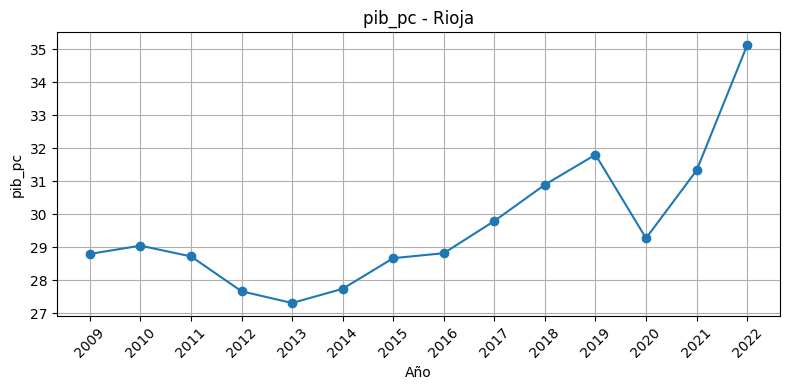

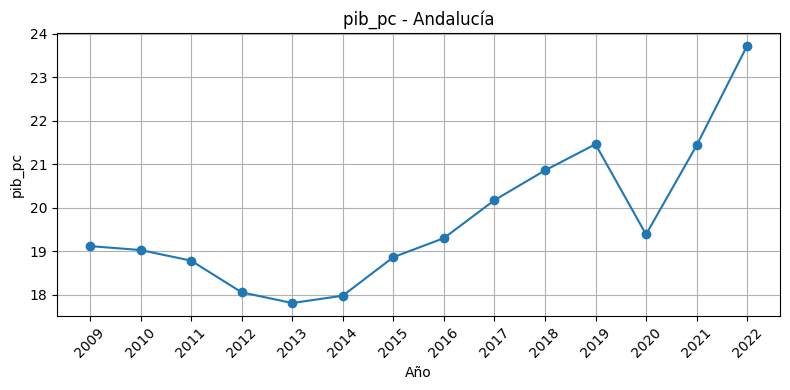

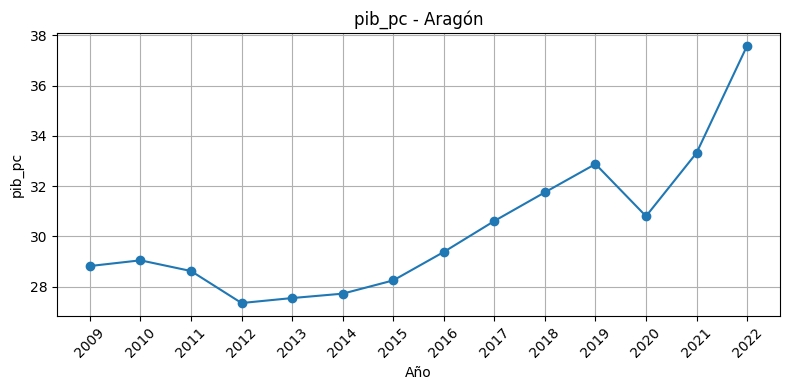

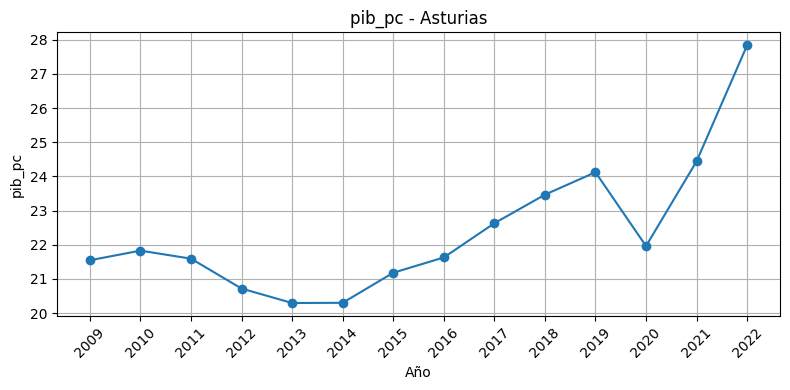

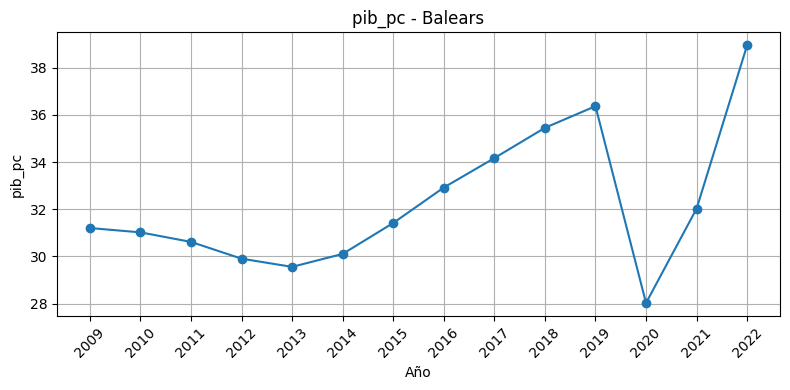

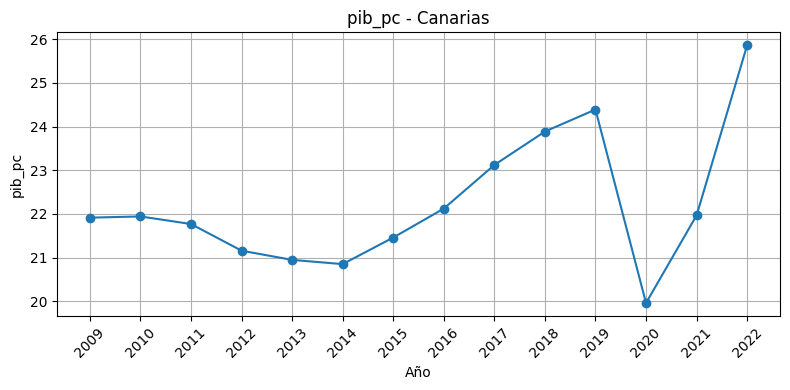

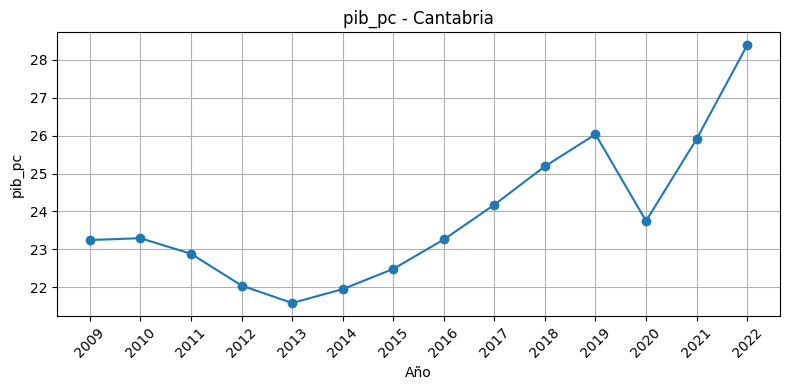

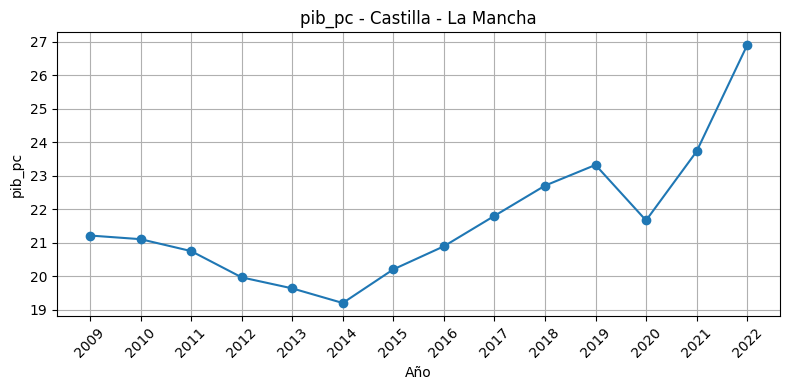

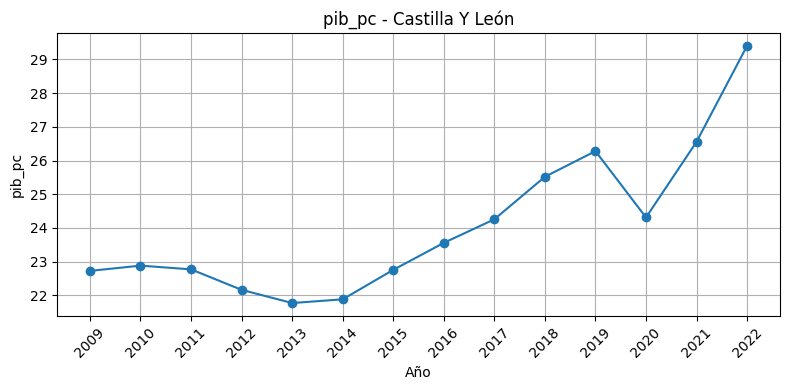

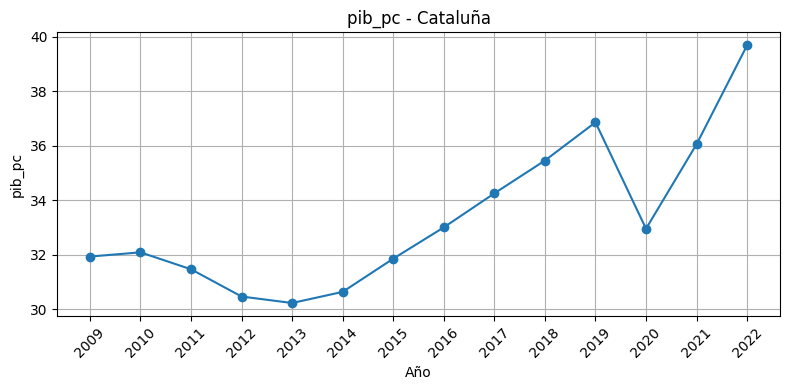

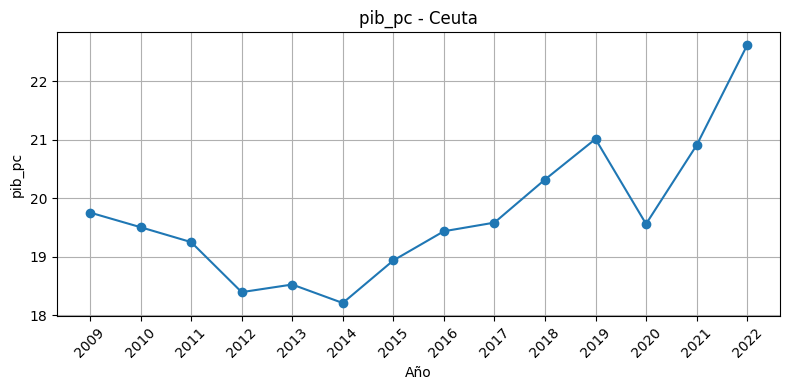

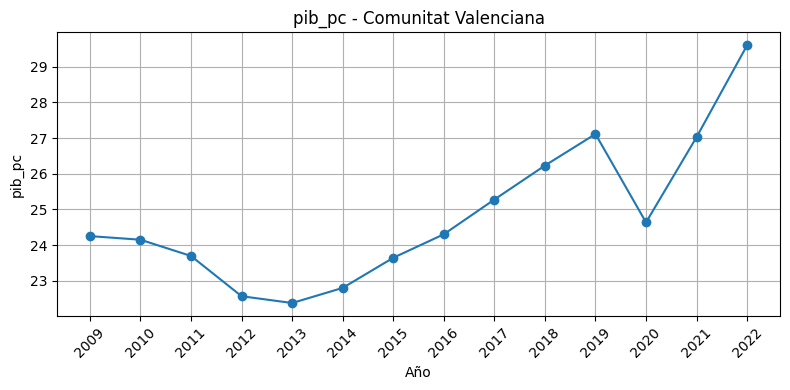

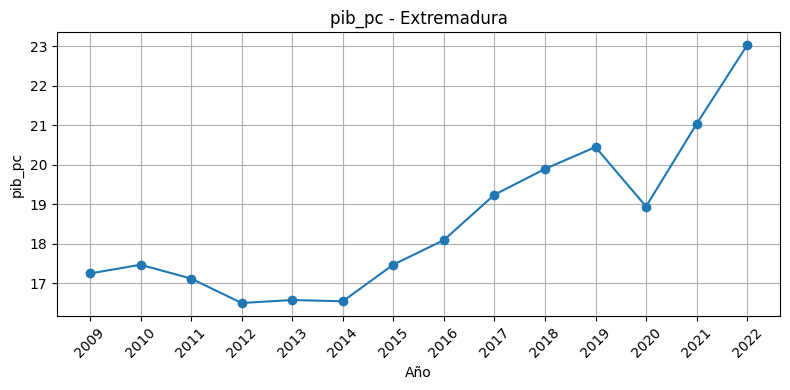

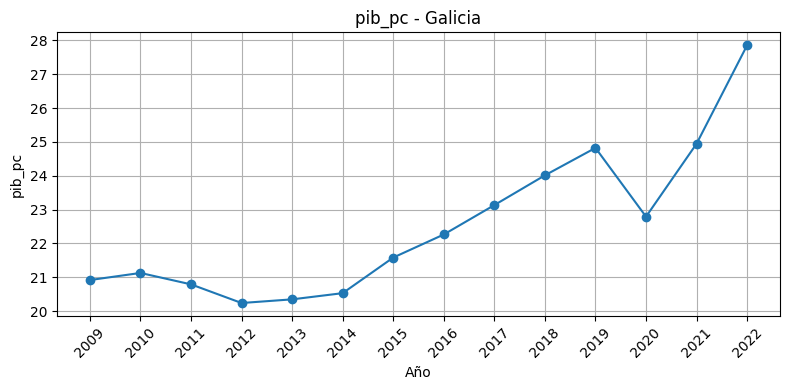

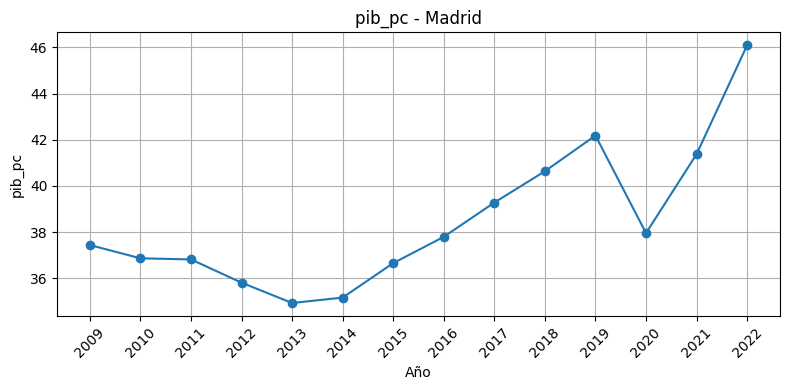

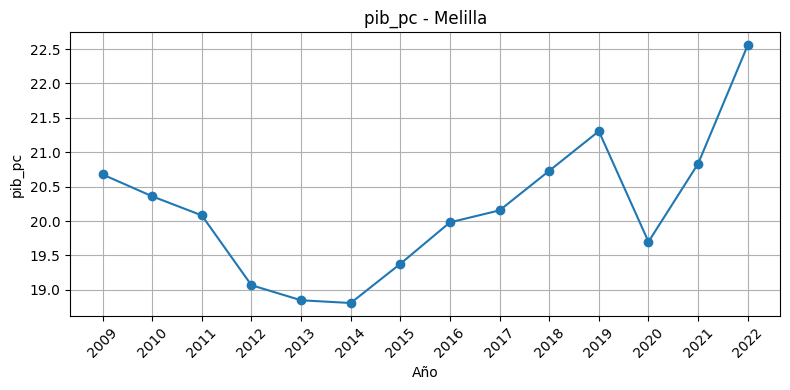

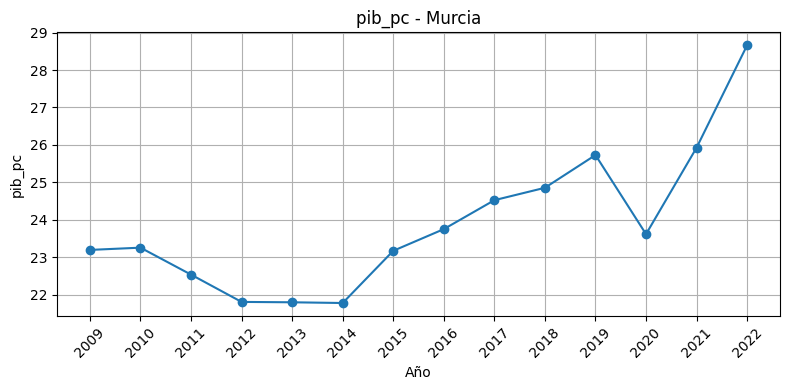

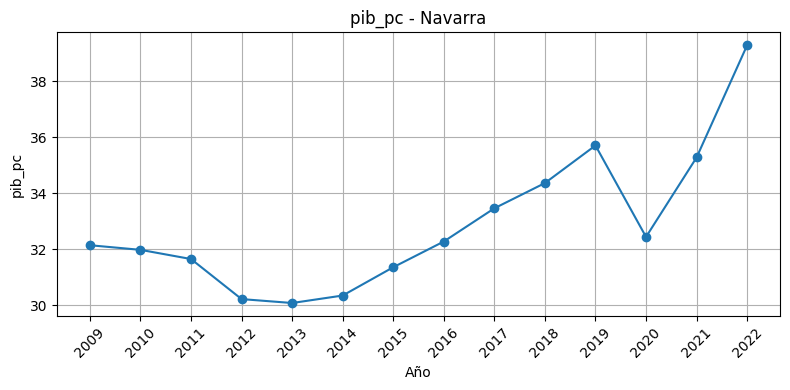

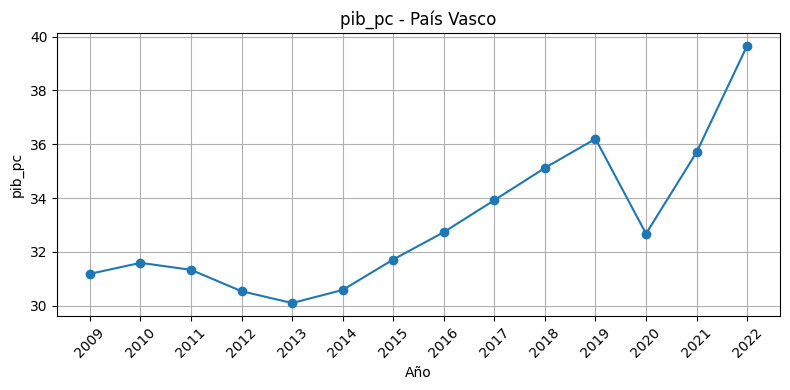

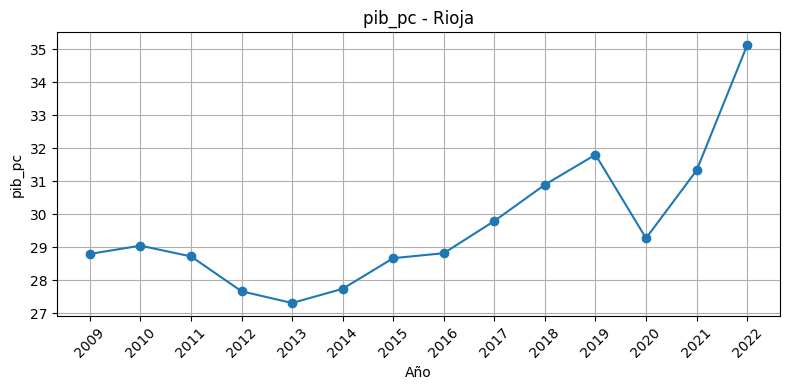

In [3]:
ut.plot_com_variable(df, comunidades ,['pib_pc'])

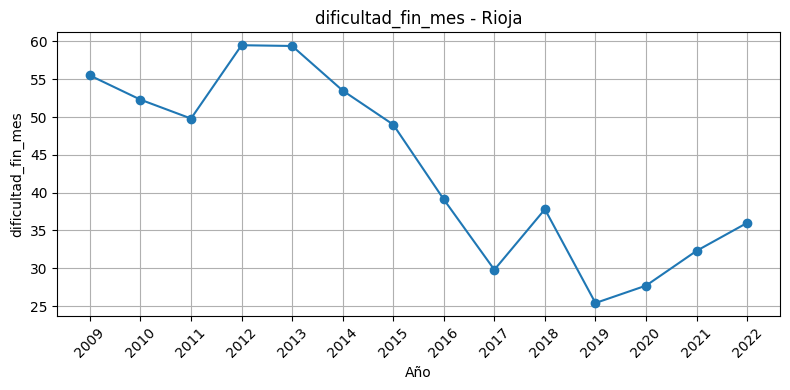

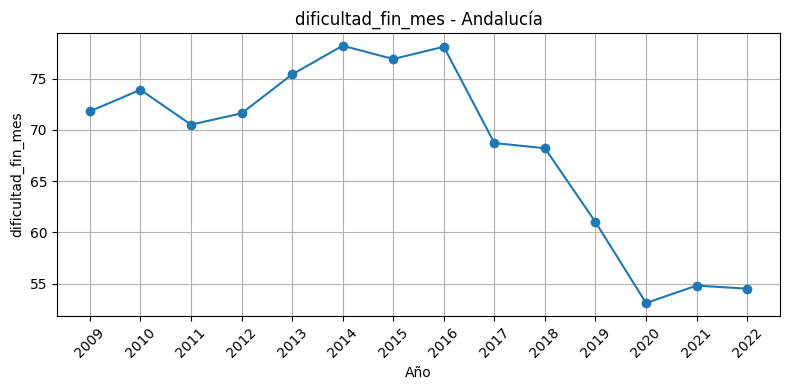

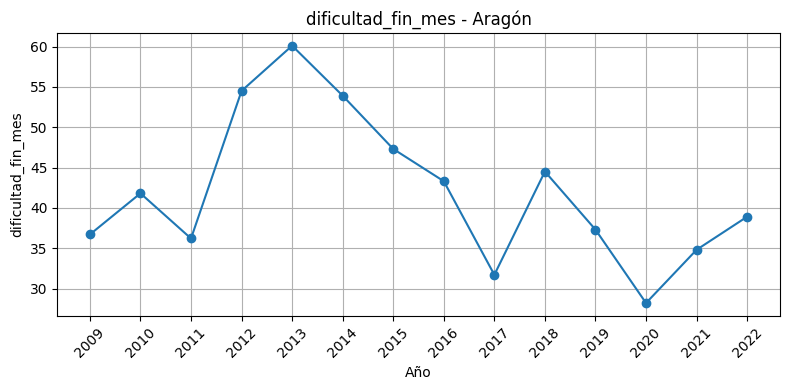

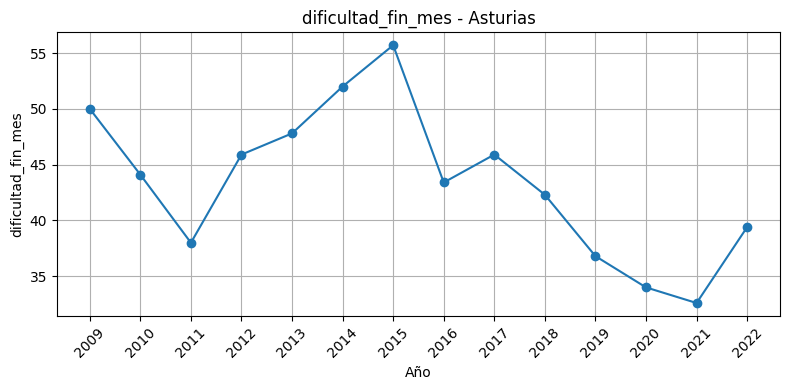

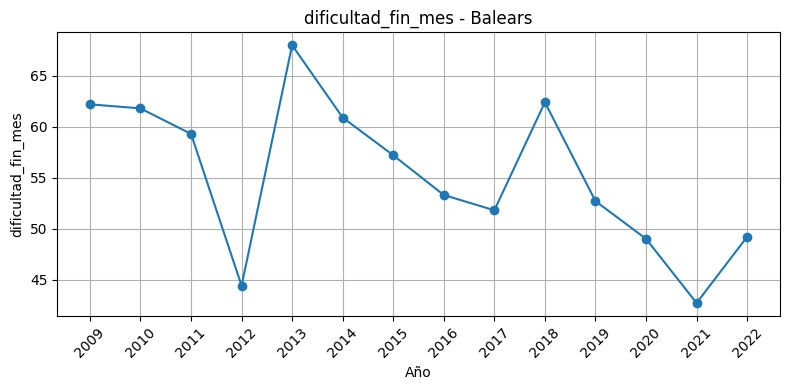

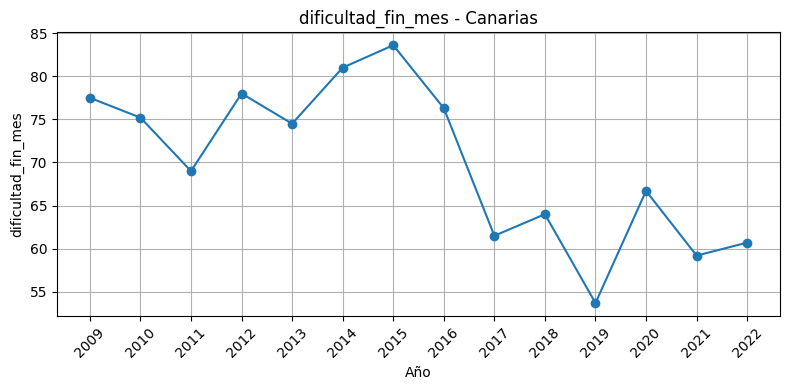

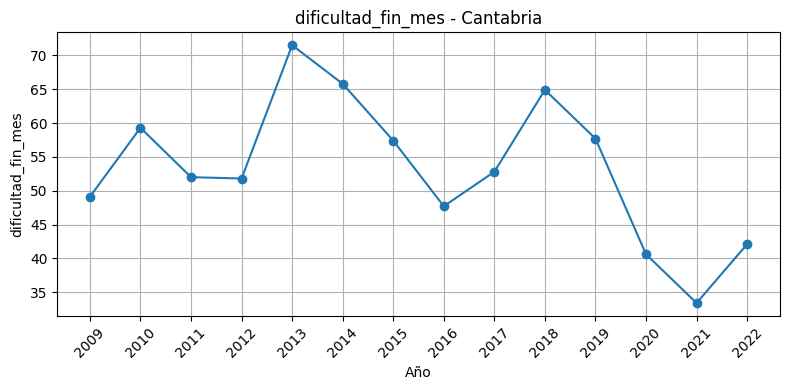

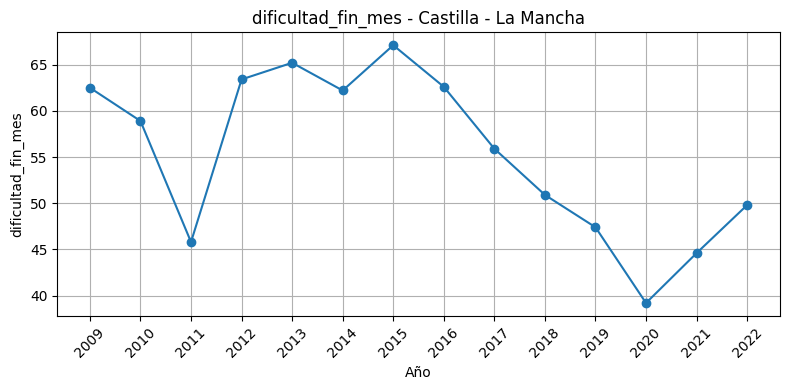

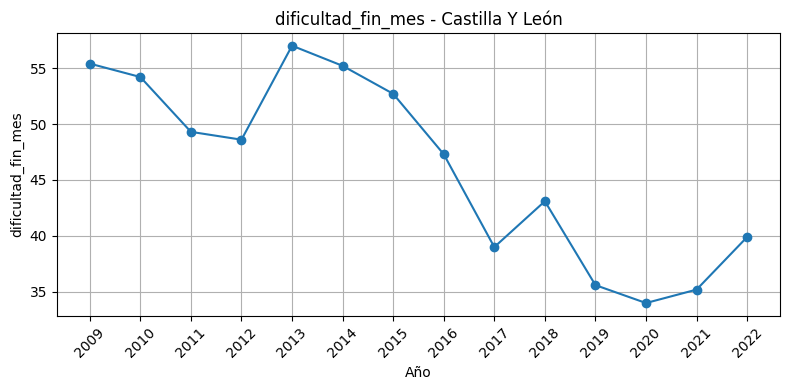

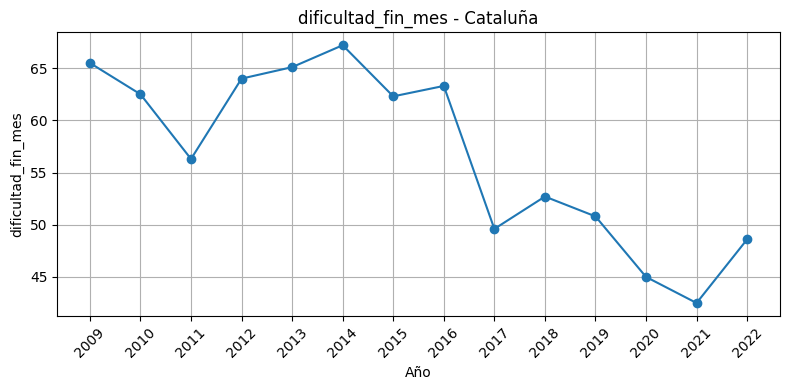

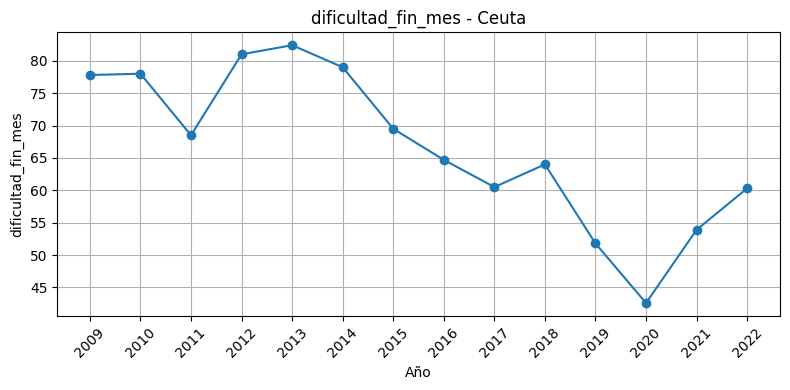

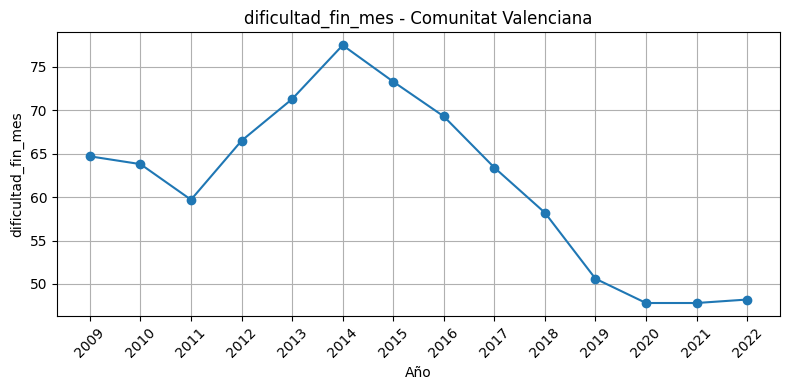

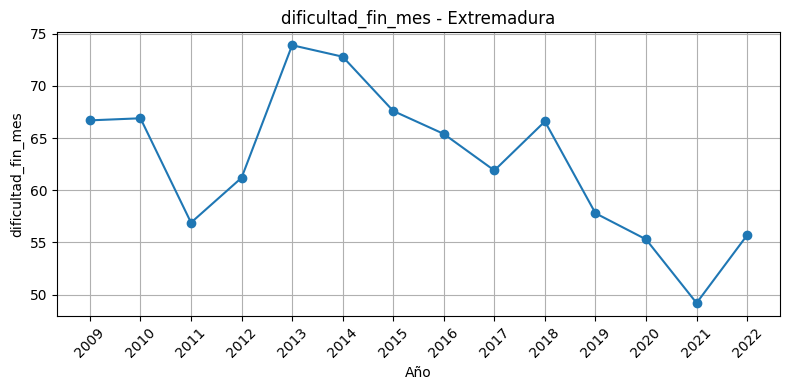

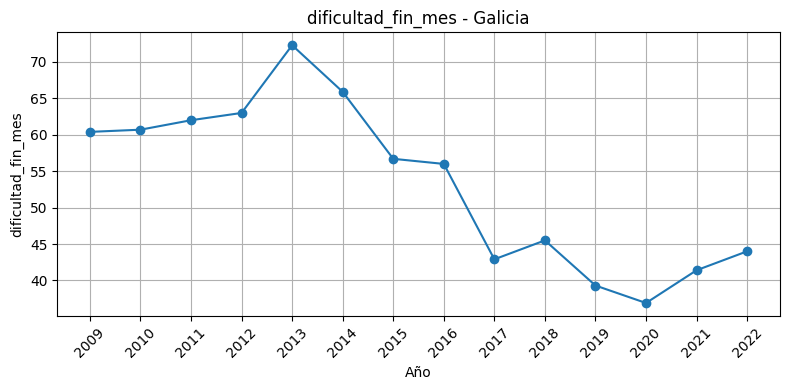

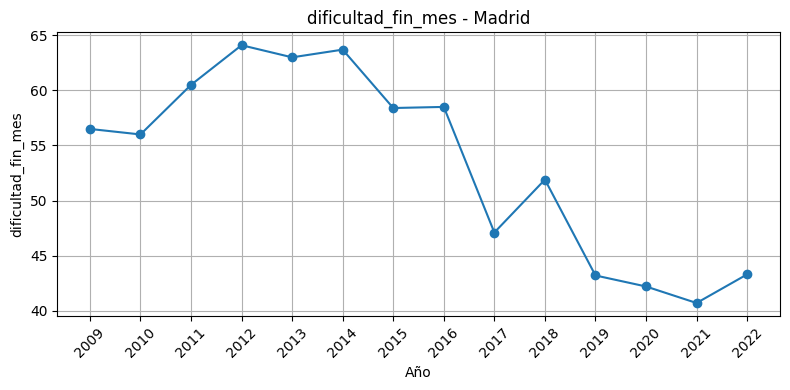

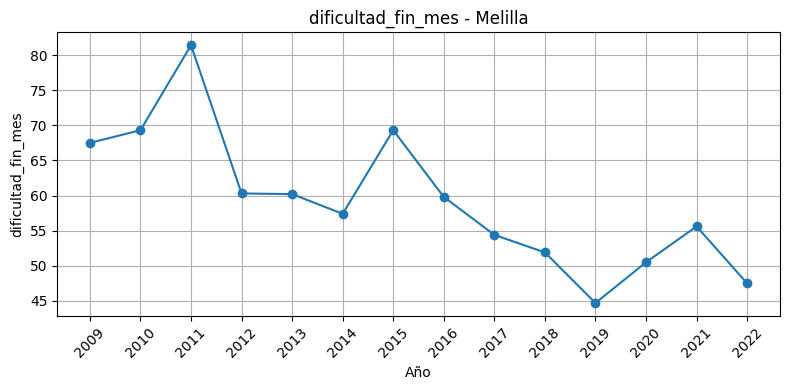

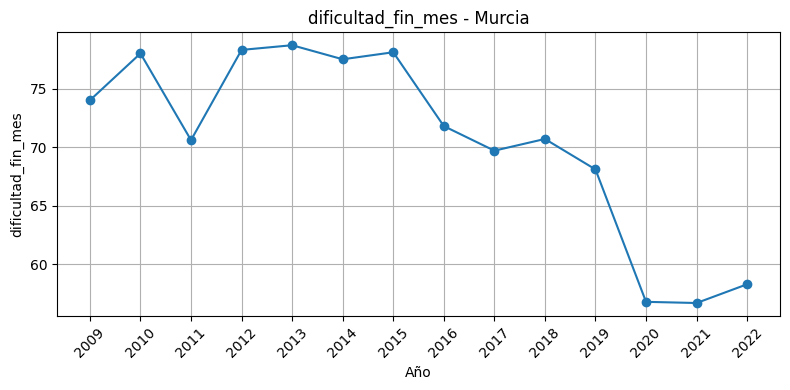

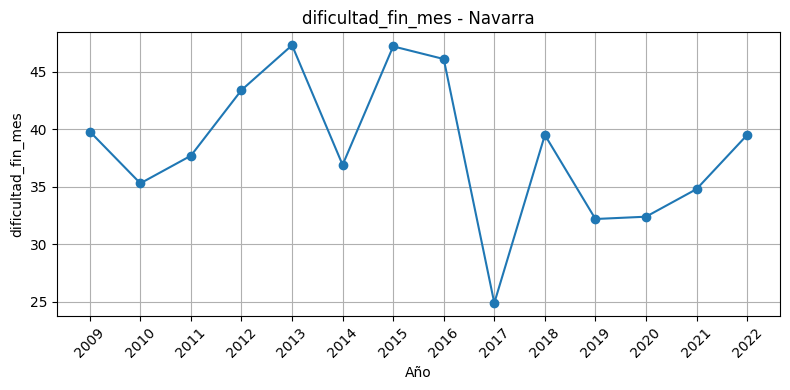

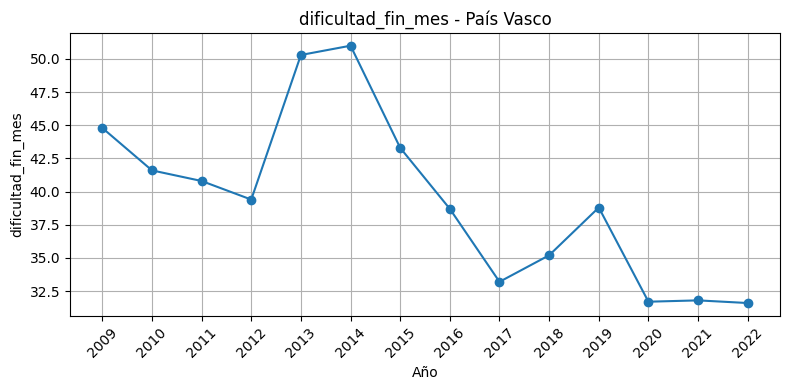

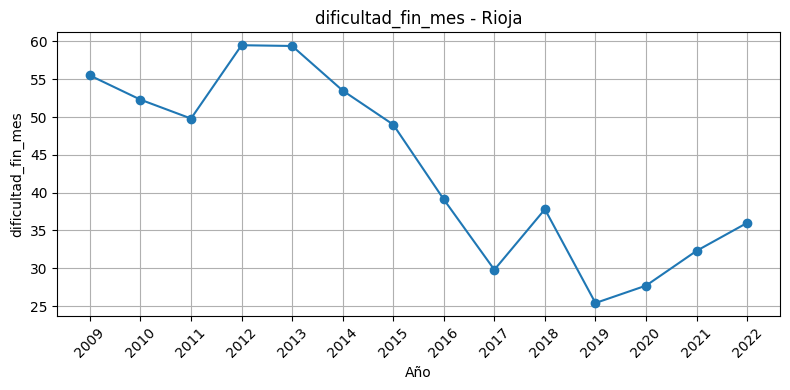

In [6]:
ut.plot_com_variable(df, comunidades ,['dificultad_fin_mes'])

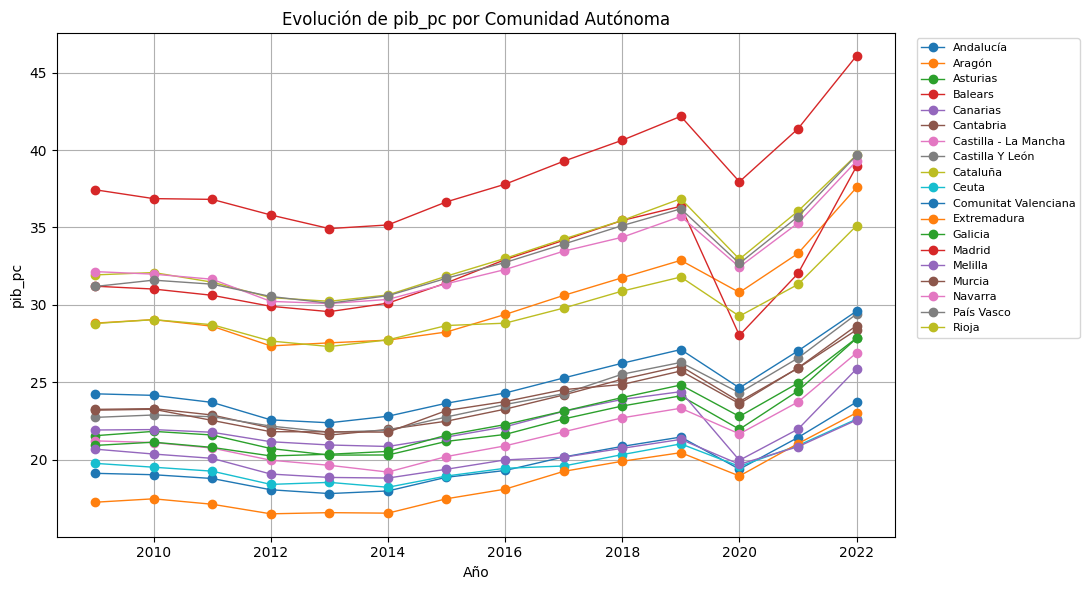

In [7]:
fig = ut.plot_todas_comunidades(df, 'pib_pc')
fig.savefig("reports/pib_pc_todas_com.png", dpi=300, bbox_inches="tight")

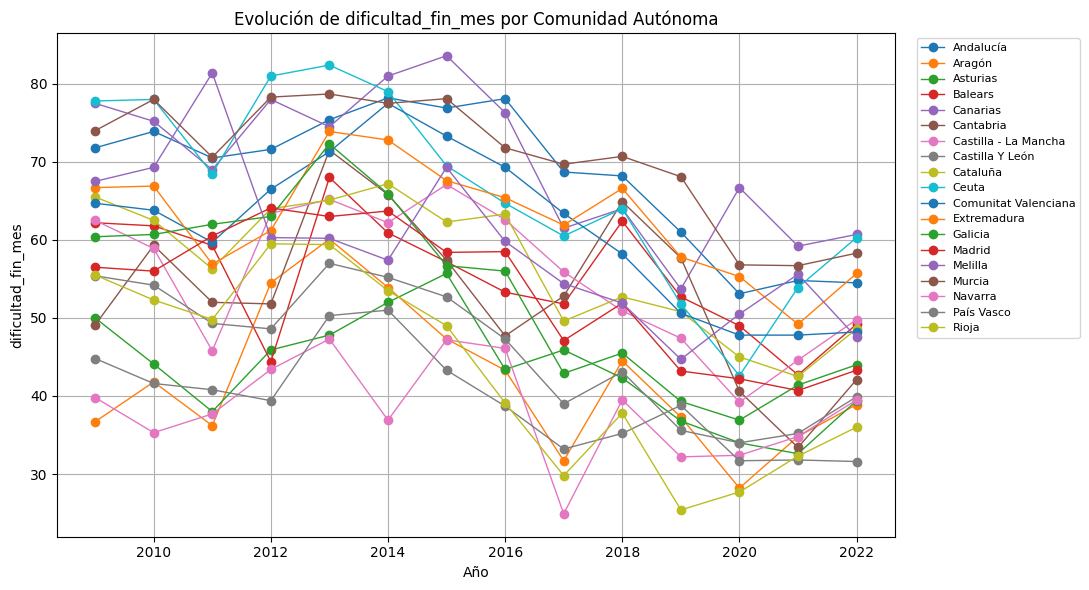

In [8]:
fig = ut.plot_todas_comunidades(df, 'dificultad_fin_mes')

In [10]:
ut.correlacion_com_bivariante(df, comunidades, 'pib_pc', 'dificultad_fin_mes',alpha = 0.05)

Coeficiente de correlación de Spearman entre pib_pc y dificultad_fin_mes

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Canarias', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [-0.745, -0.622, -0.767, -0.64, -0.679, -0.846, -0.754, -0.771, -0.801, -0.578, -0.877, -0.868, -0.78, -0.559, -0.793, -0.837]


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Balears', 'Cantabria', 'Melilla']
 [0.681, 0.122, 0.118]


#### A medida que aumenta el PIB per cápita, disminuye el porcentaje de población con dificultad para llegar a fin de mes.

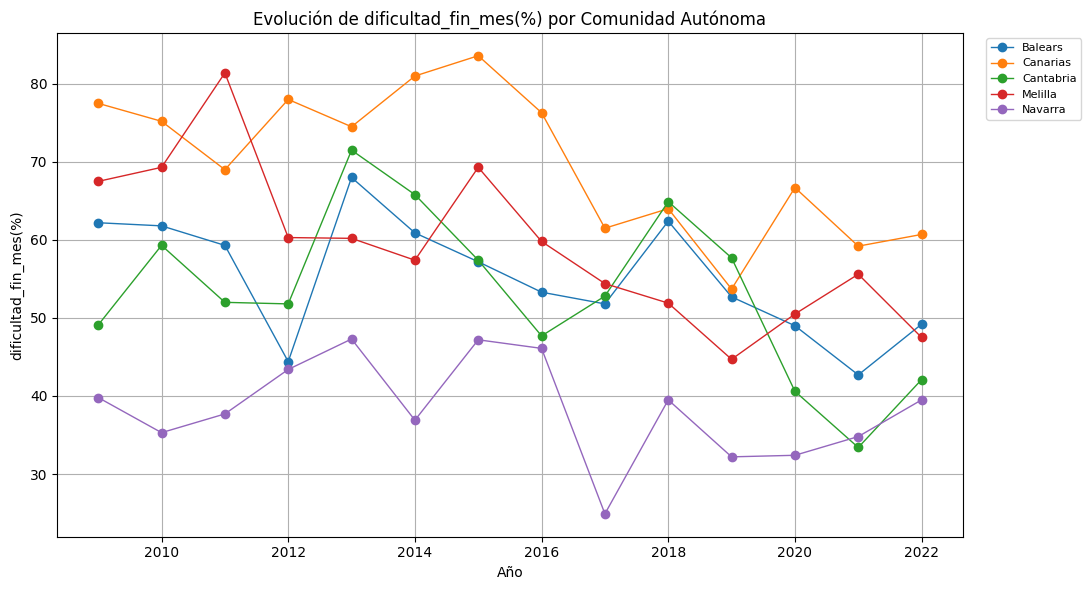

In [23]:
fig = ut.plot_todas_comunidades(df, 'dificultad_fin_mes(%)',['Balears','Canarias','Cantabria','Melilla','Navarra'])

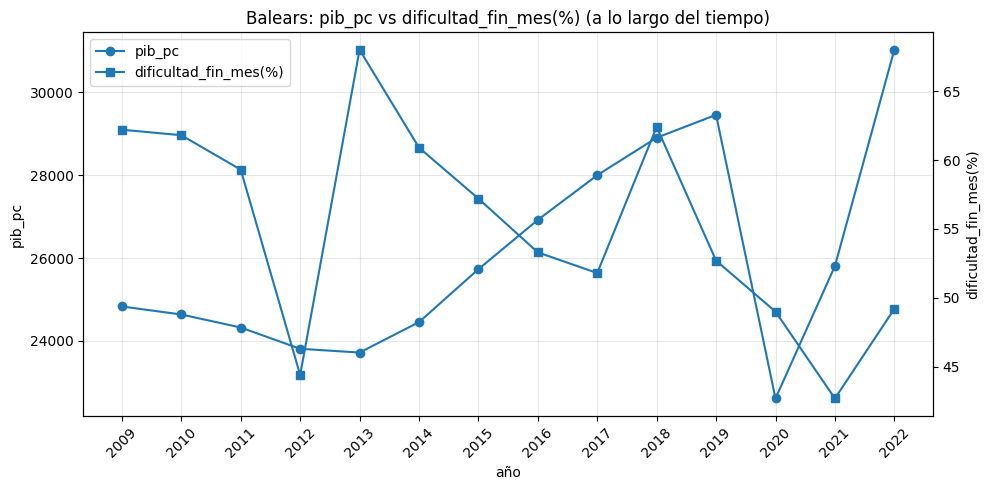

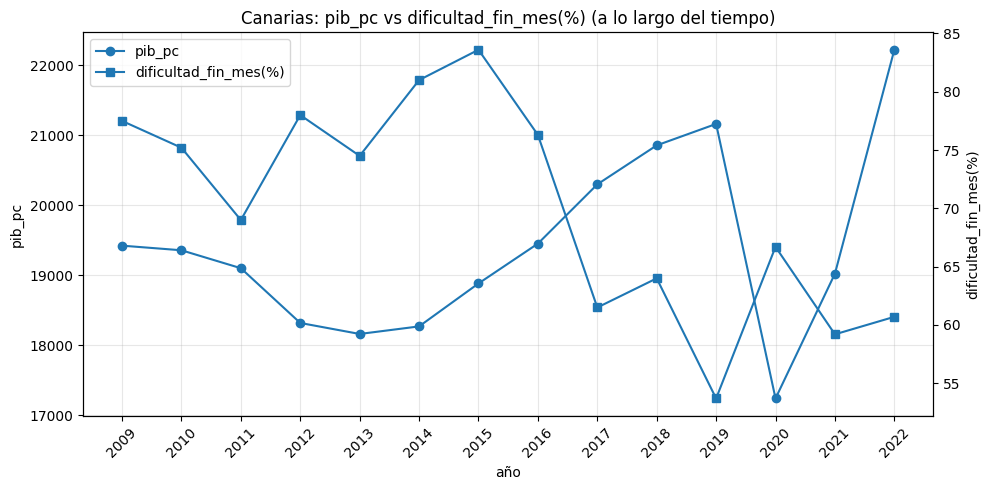

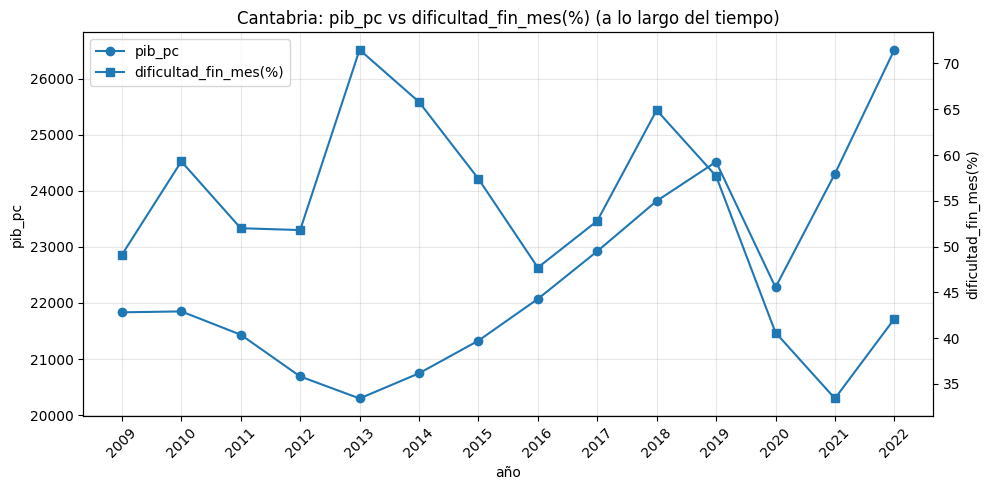

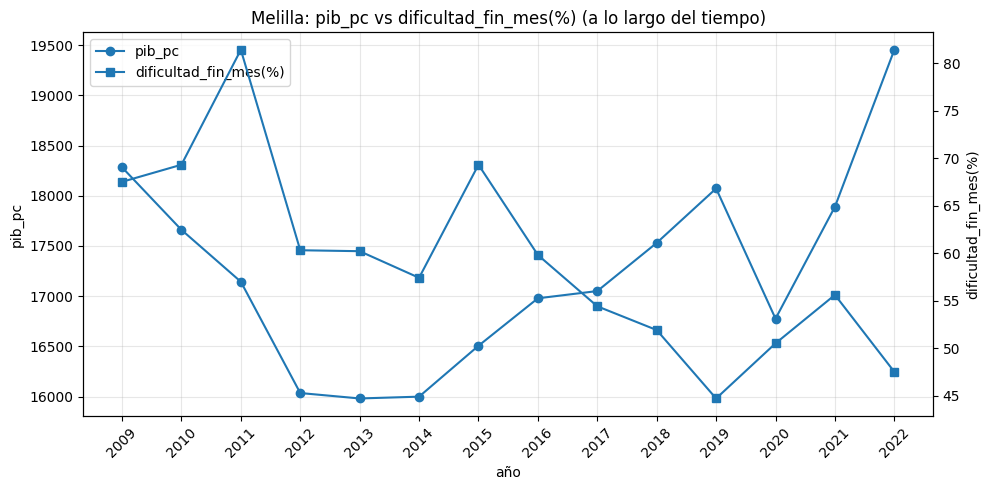

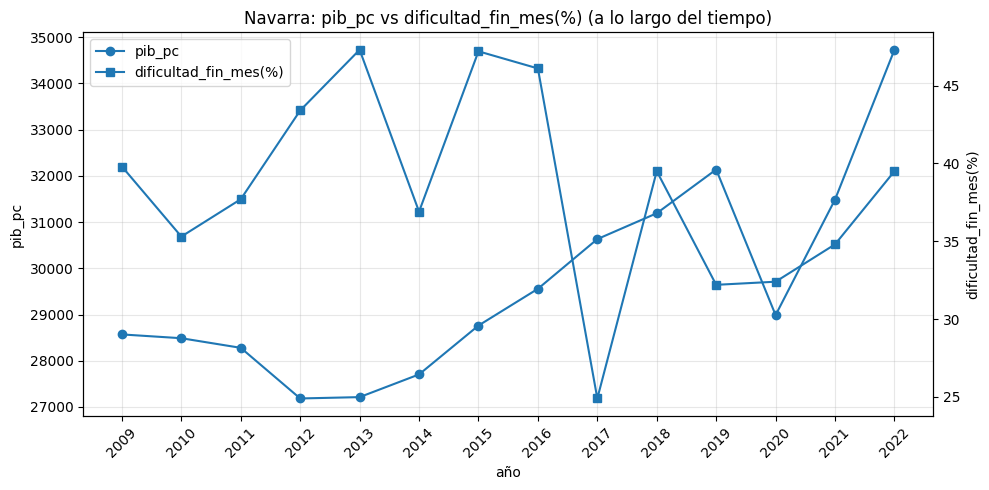

In [24]:
fig = ut.plot_dual_axis(df,['Balears','Canarias','Cantabria','Melilla','Navarra'], "pib_pc", "dificultad_fin_mes(%)", x="año")


### Hipótesis 2: PIB per cápita y desigualdad de ingresos

- **Hipótesis nula (H₀₂):**  
  No existe correlación entre el PIB per cápita y el nivel de desigualdad de ingresos (S80/S20) en las comunidades autónomas a lo largo del tiempo.

- **Hipótesis alternativa (H₁₂):**  
  Existe una relación no necesariamente negativa entre el PIB per cápita y el nivel de desigualdad de ingresos, observándose patrones heterogéneos entre comunidades autónomas.

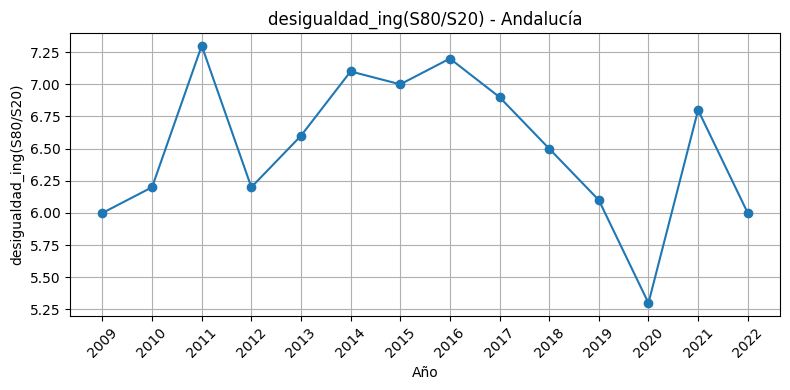

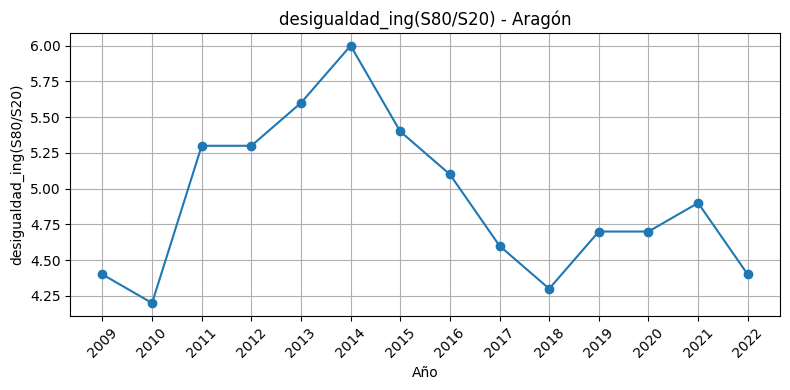

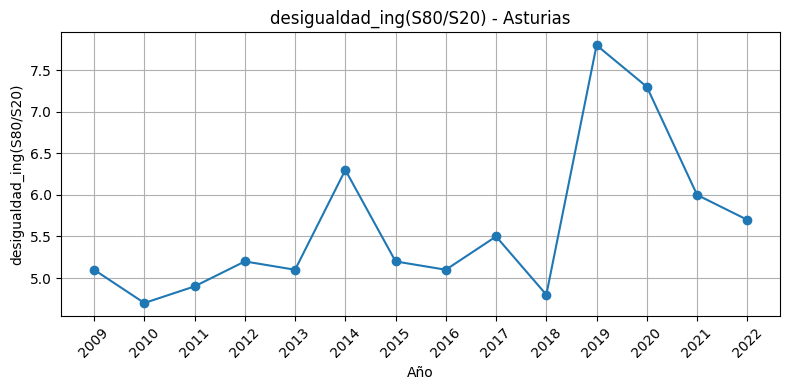

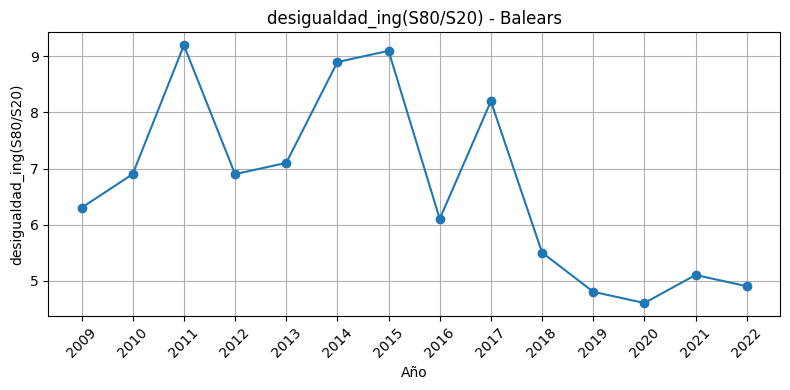

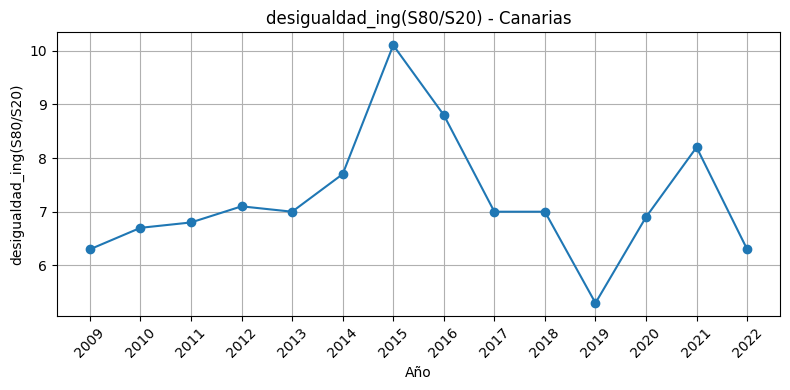

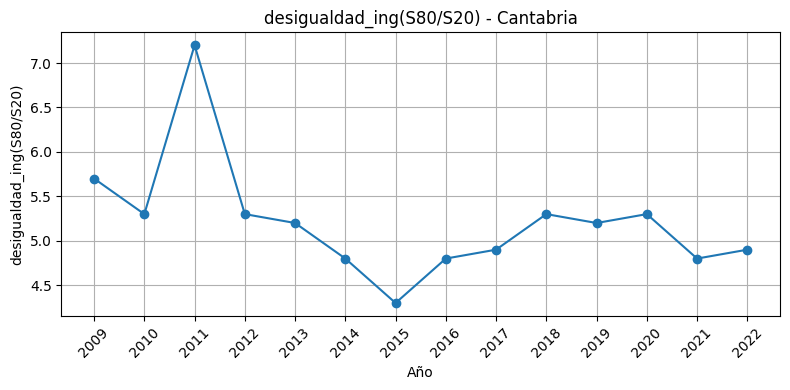

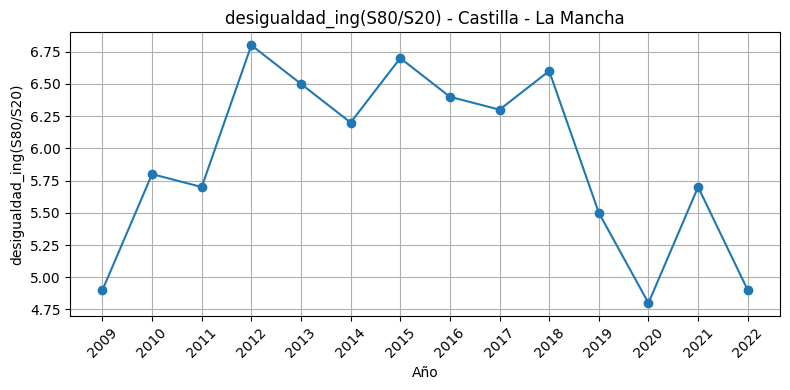

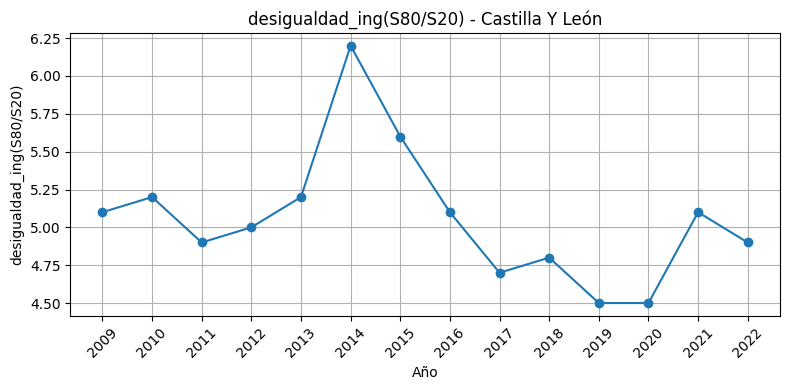

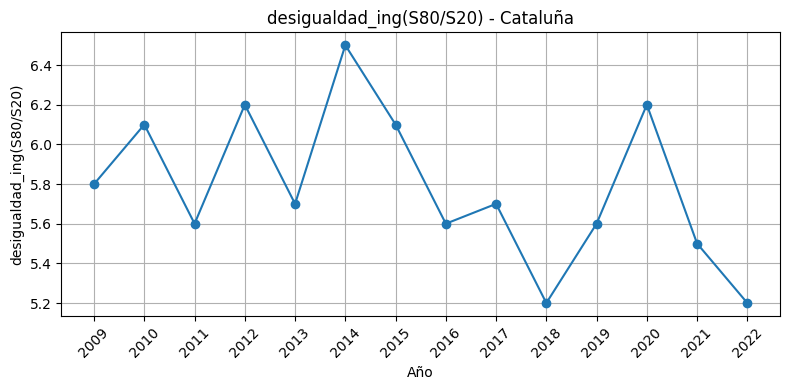

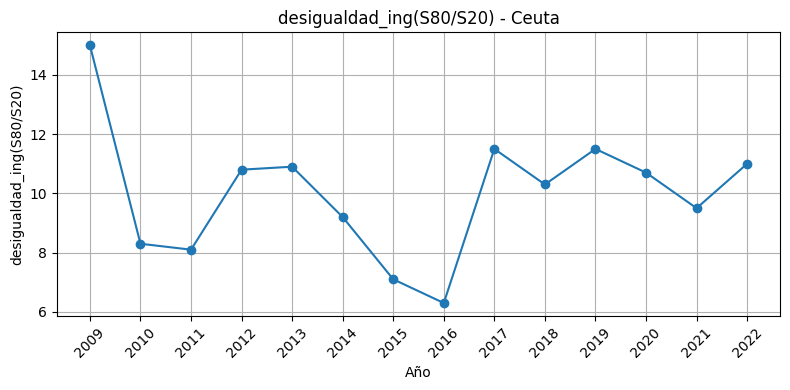

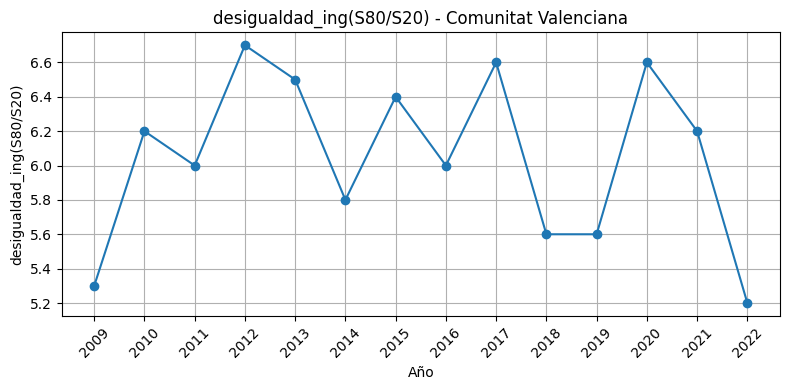

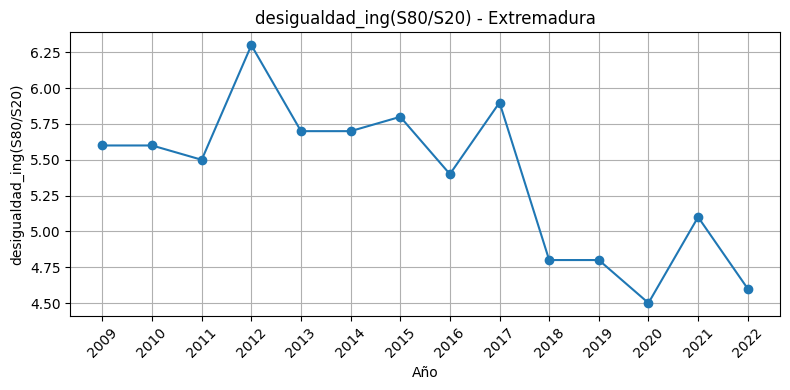

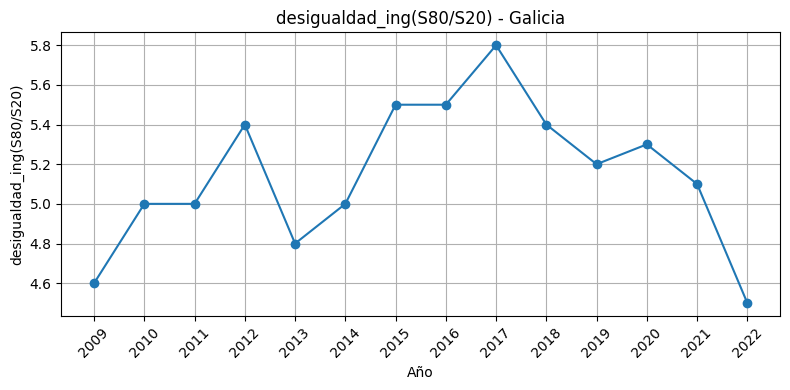

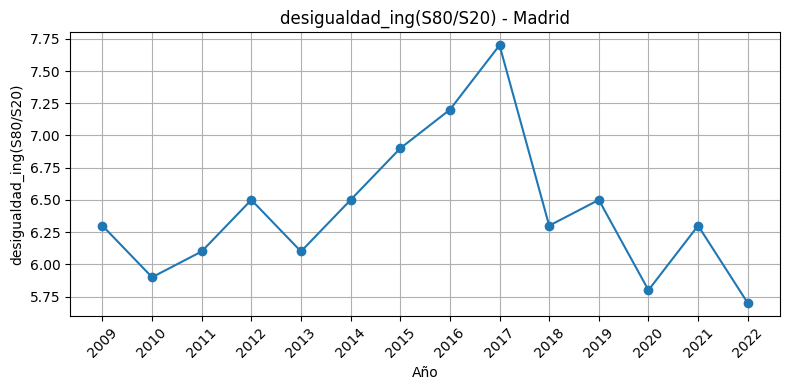

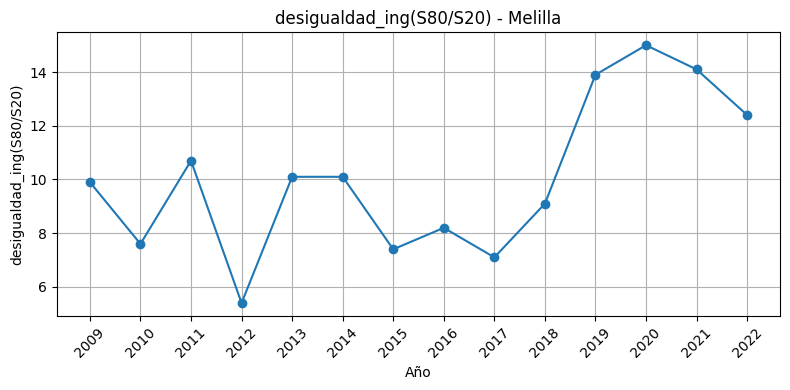

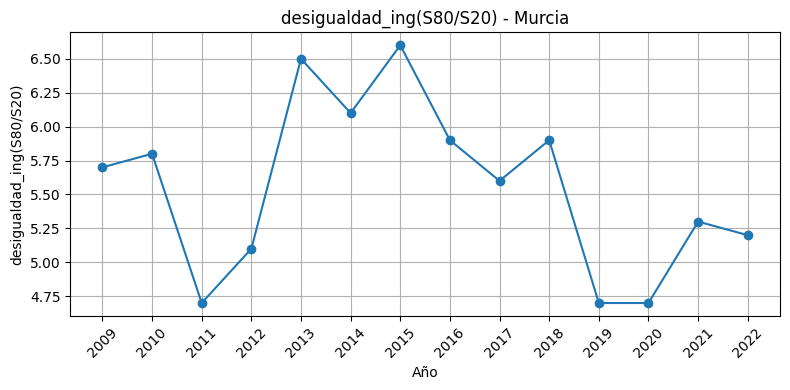

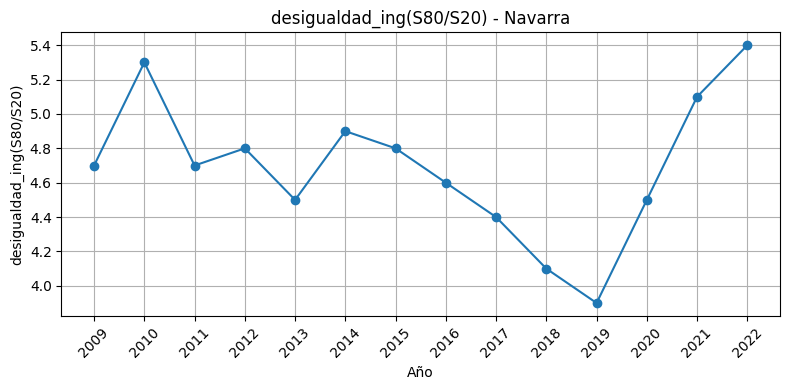

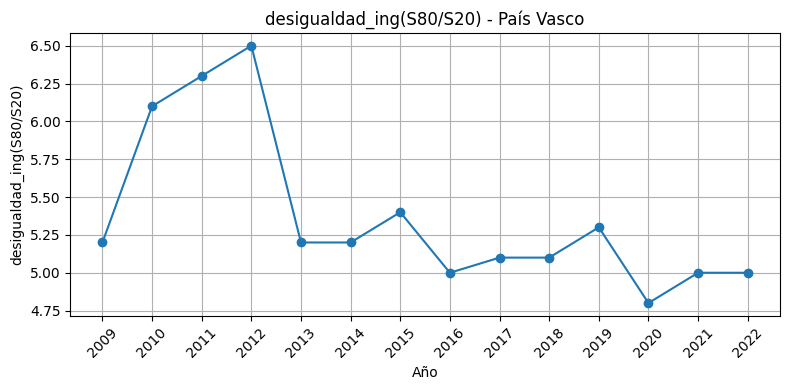

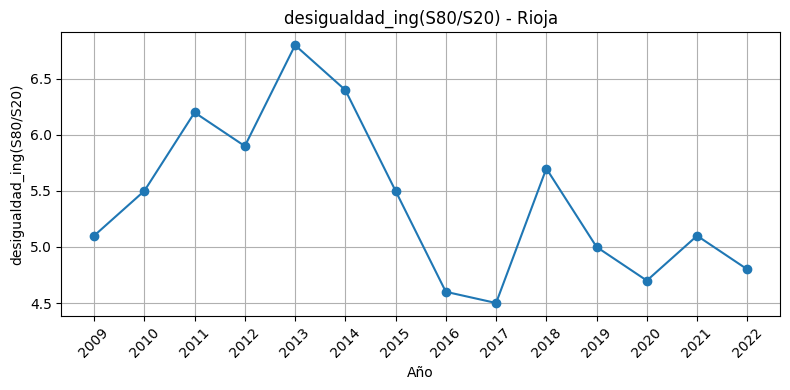

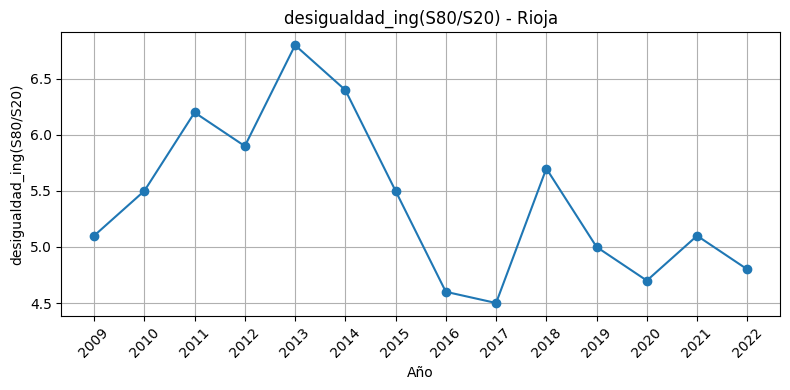

In [11]:
ut.plot_com_variable(df, comunidades ,['desigualdad_ing(S80/S20)'])


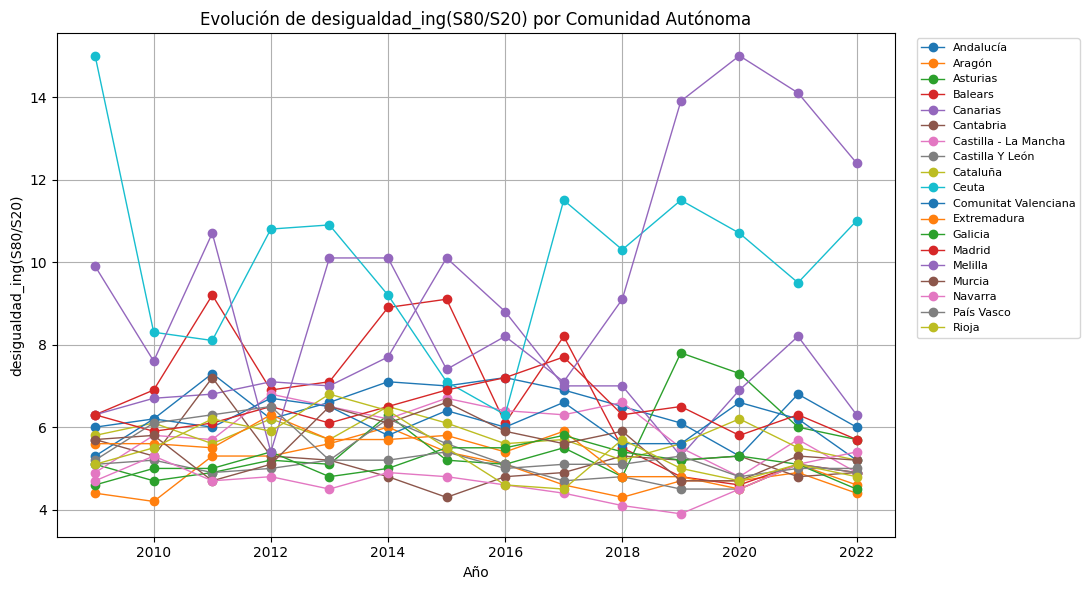

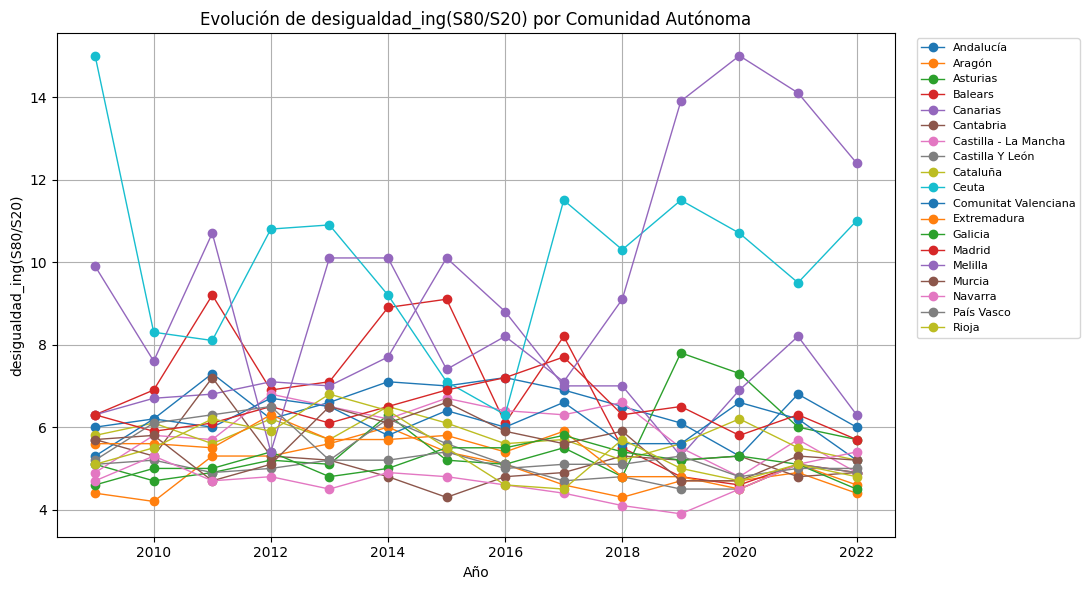

In [15]:
ut.plot_todas_comunidades(df, 'desigualdad_ing(S80/S20)')

In [19]:
ut.correlacion_com_bivariante(df, comunidades, 'pib_pc', 'desigualdad_ing(S80/S20)',alpha = 0.05)


En Andalucía, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Aragón, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 correlacion negativa significativa
En Asturias, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Balears, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Canarias, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Cantabria, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Castilla - La Mancha, para las variables pib_pc y desigualdad

Los análisis de correlación entre el PIB per cápita y el índice de desigualdad de ingresos (S80/S20) muestran resultados heterogéneos entre comunidades autónomas. En la mayoría de las comunidades no se encontró evidencia estadísticamente significativa de correlación (p ≥ 0,05), por lo que no se rechaza la hipótesis nula en dichos casos.

Sin embargo, en un subconjunto de comunidades se observó una correlación negativa estadísticamente significativa (p < 0,05), lo que indica que, en estos territorios, un mayor PIB per cápita se asocia con menores niveles de desigualdad de ingresos. Estos resultados sugieren que el impacto del crecimiento económico sobre la desigualdad no es uniforme y depende del contexto territorial.


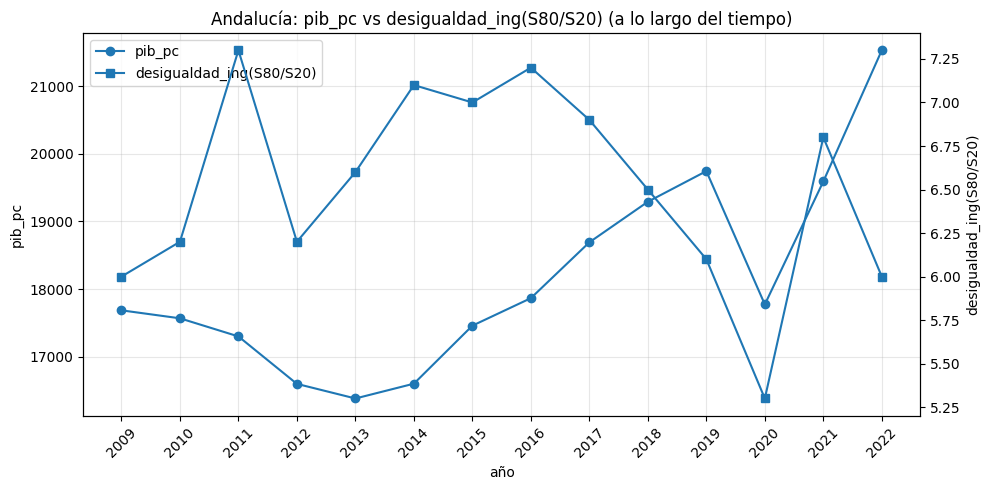

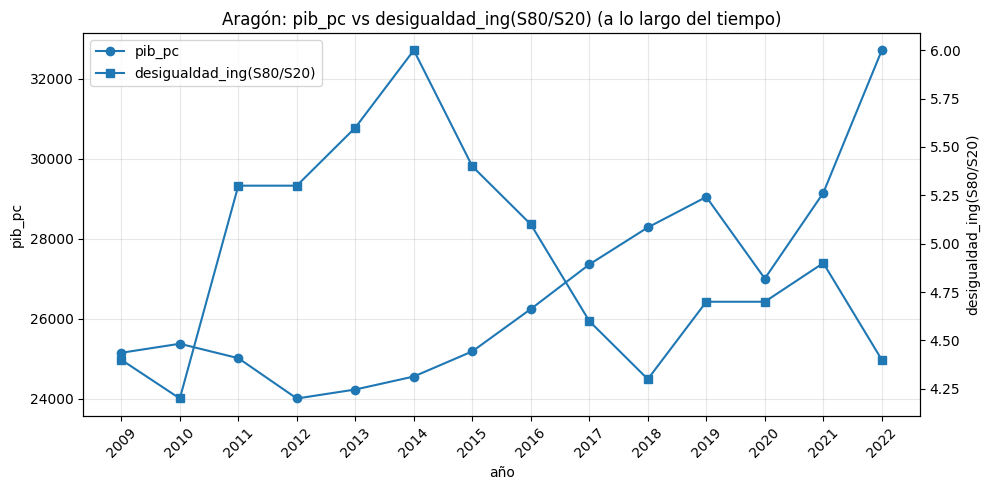

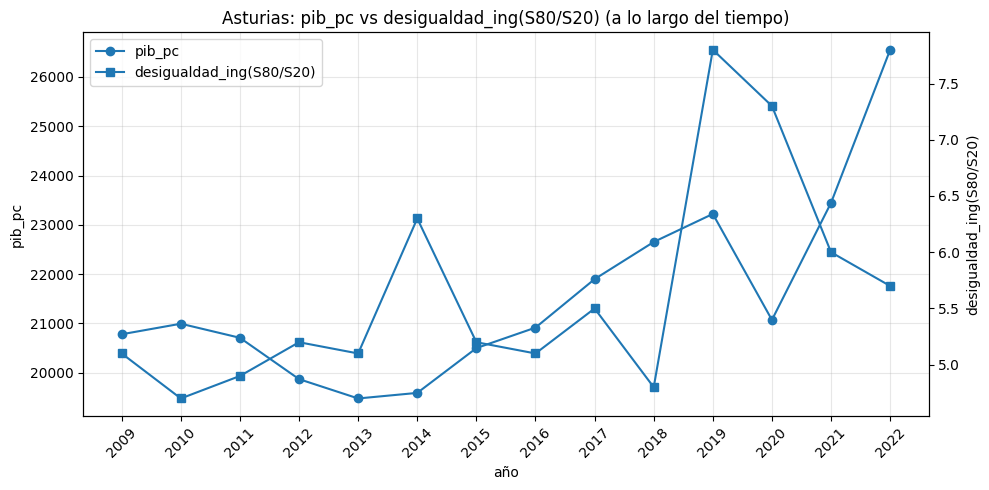

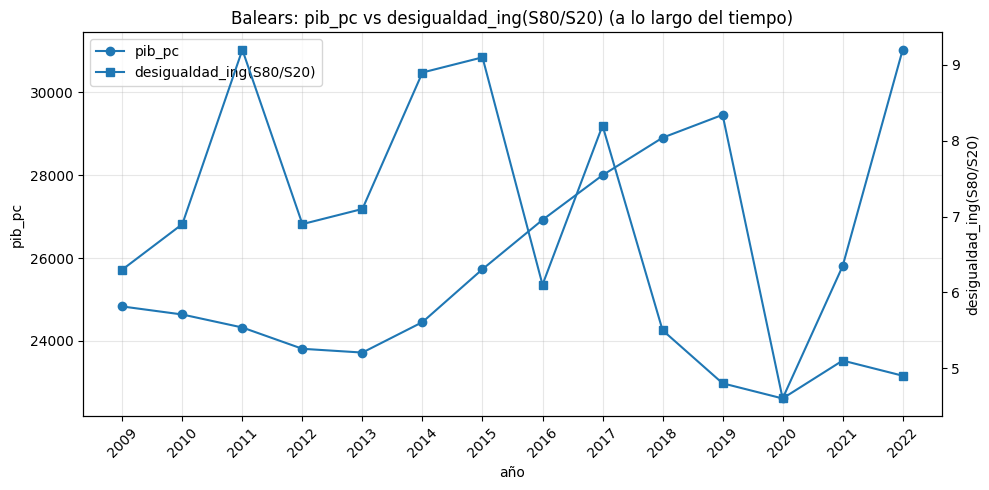

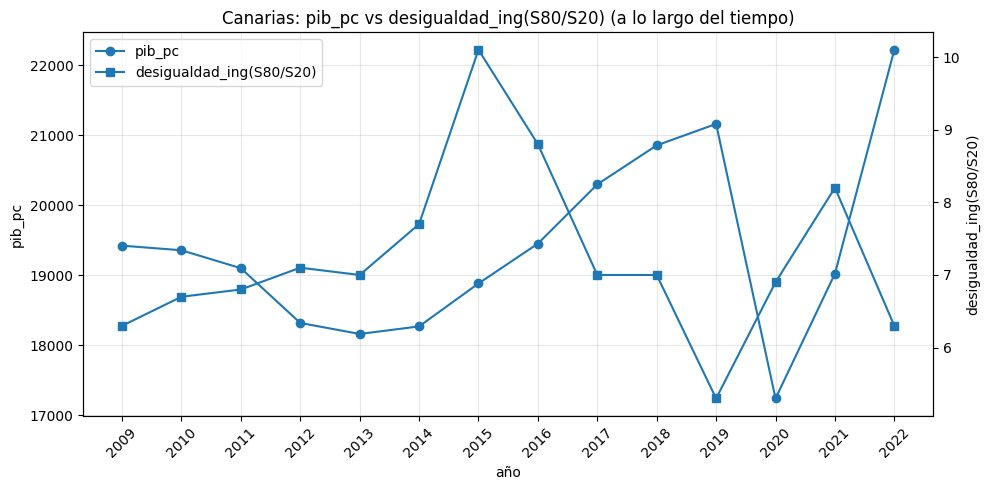

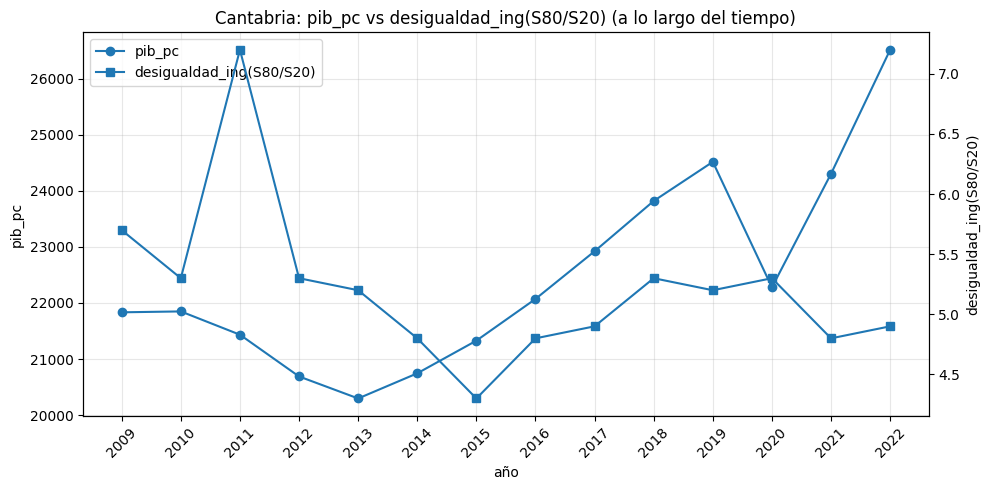

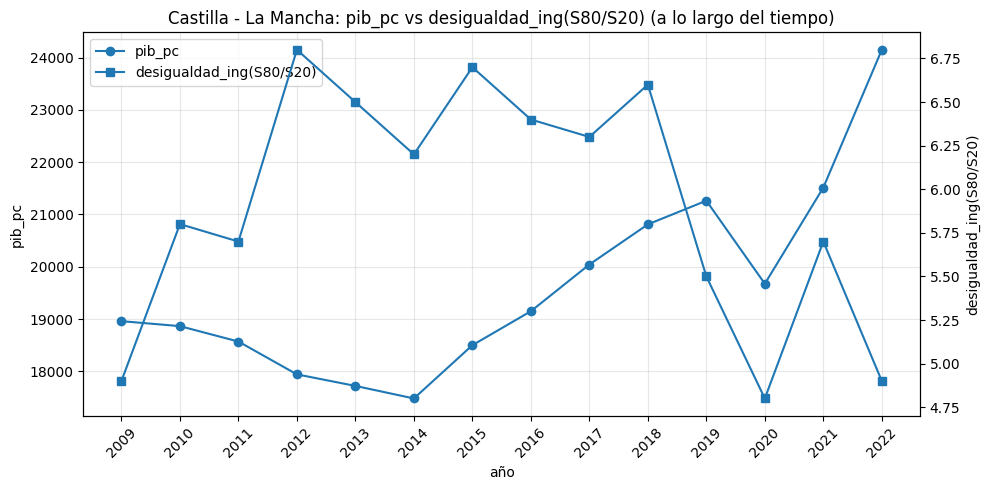

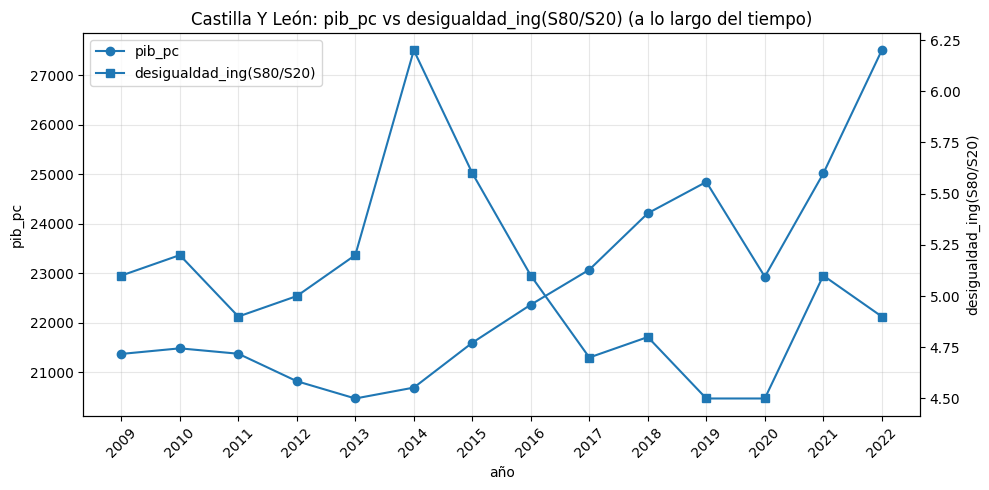

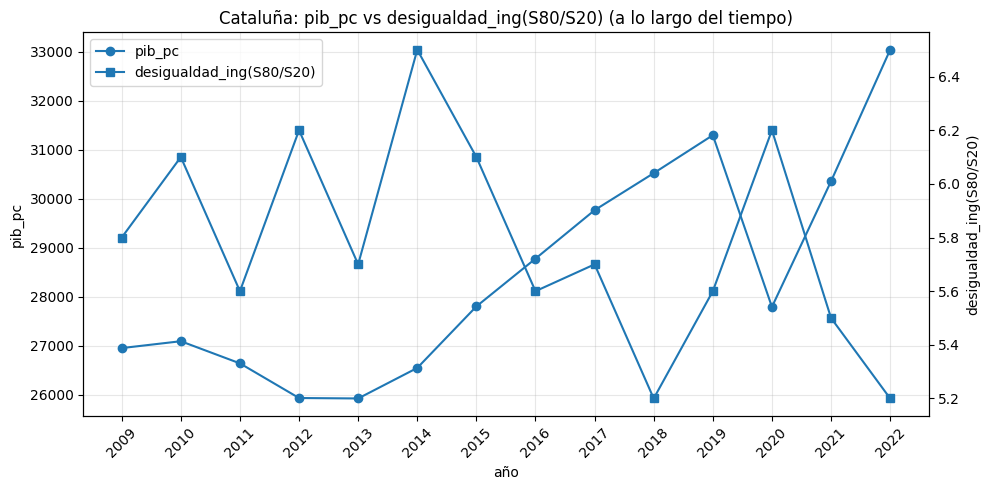

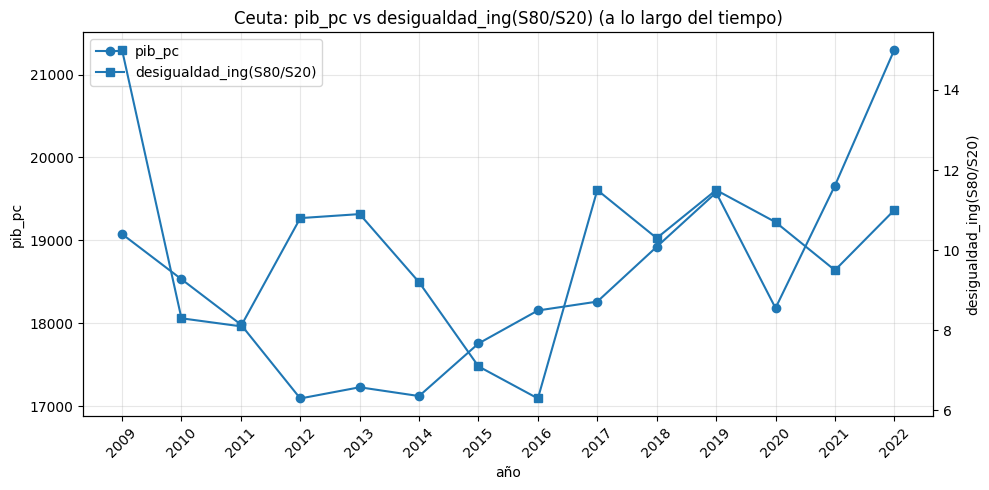

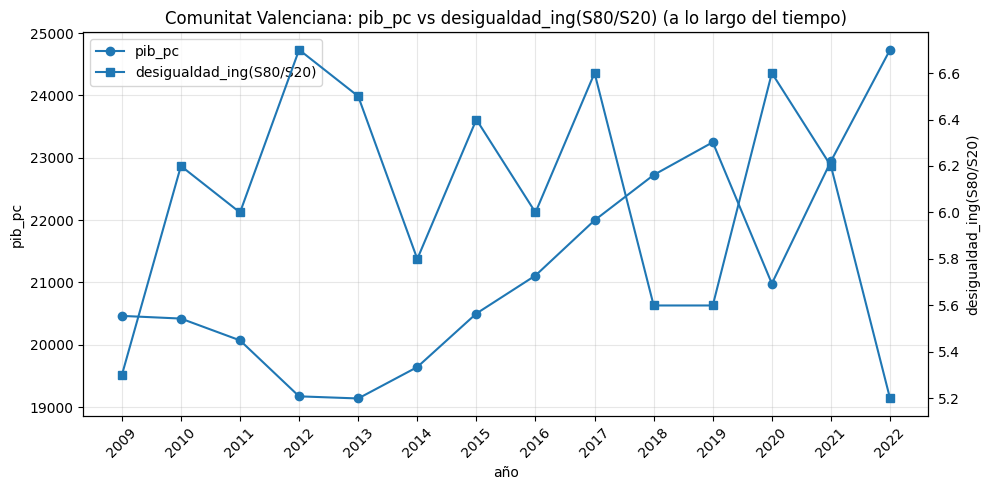

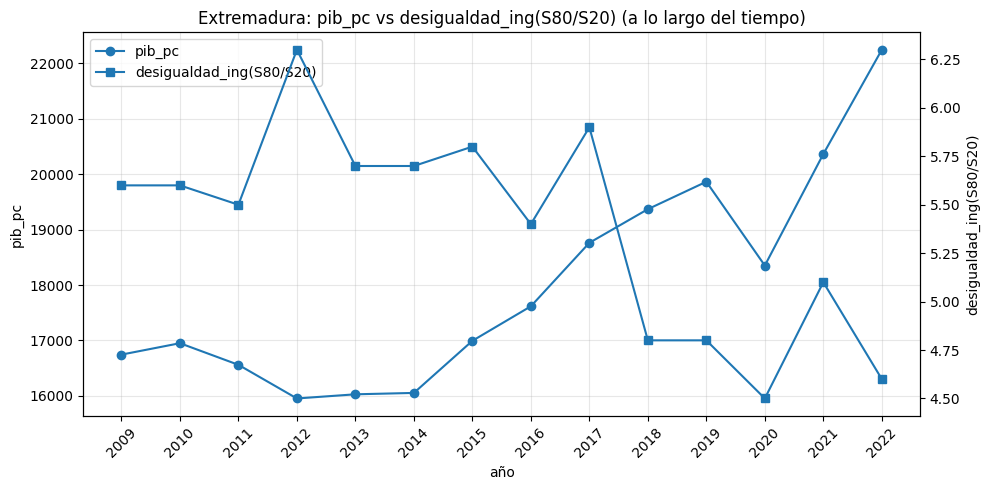

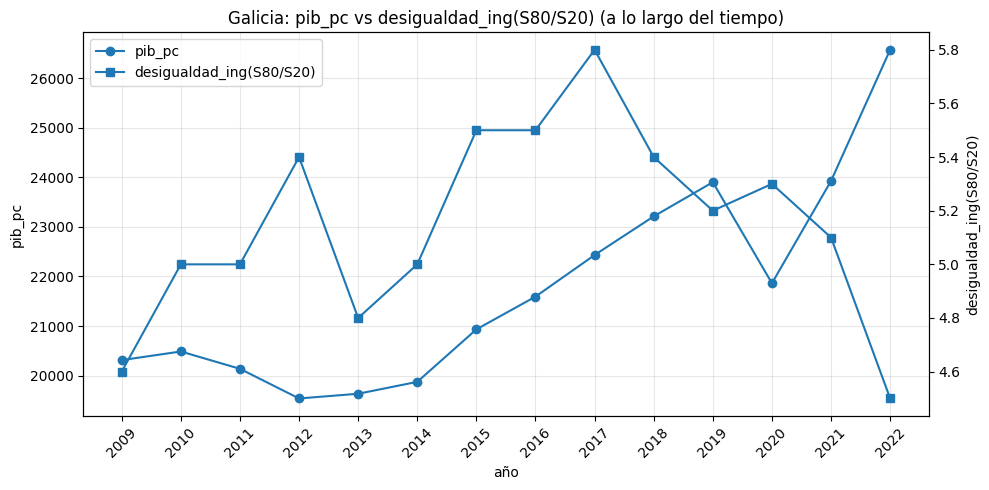

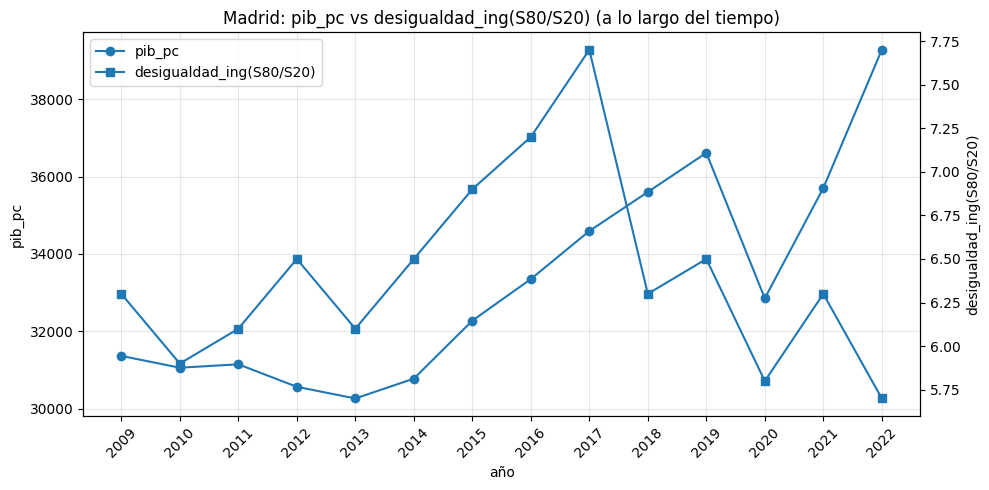

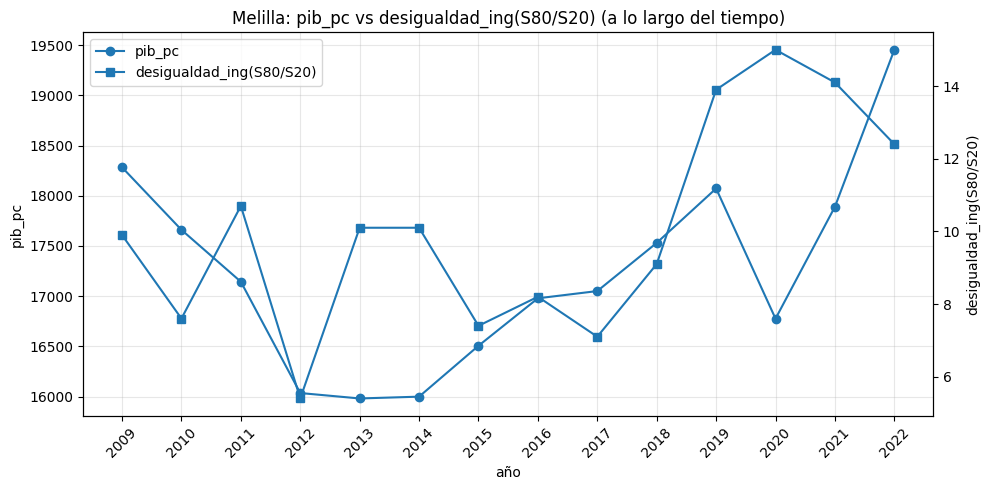

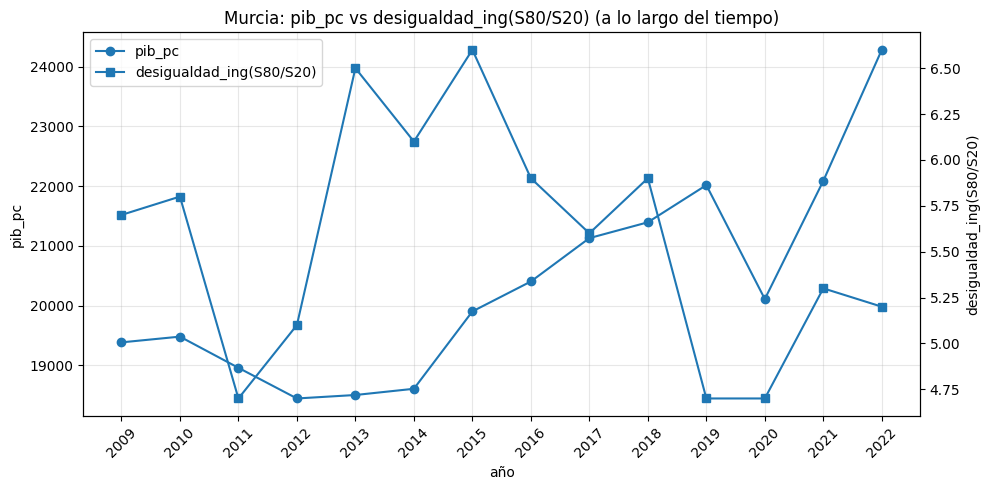

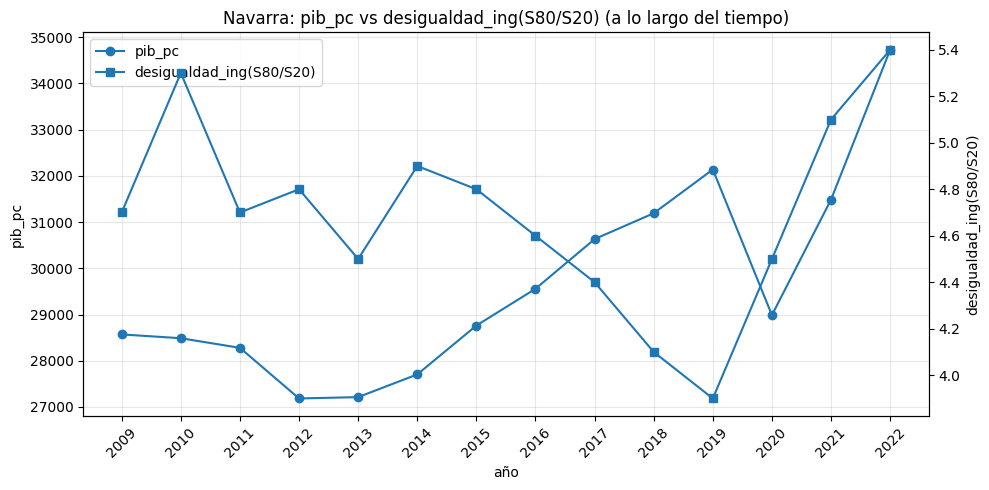

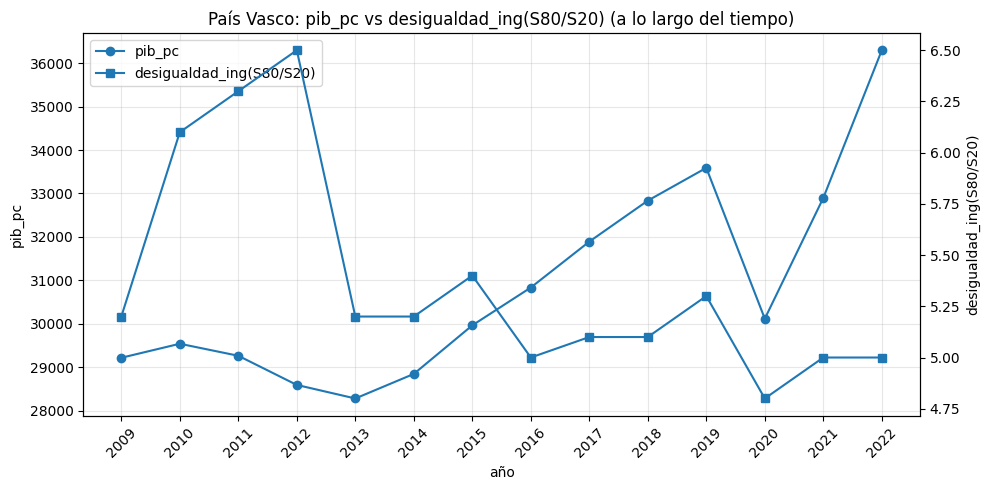

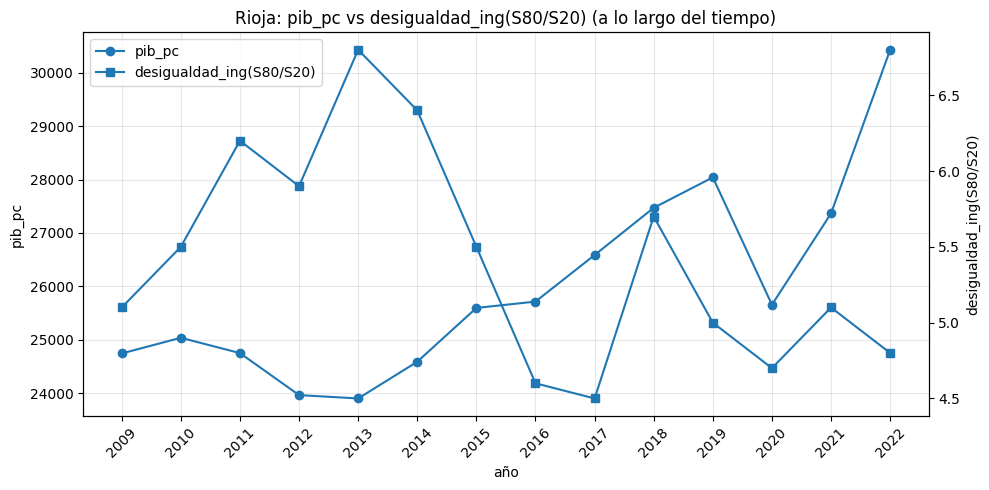

In [3]:
fig = ut.plot_dual_axis(df,comunidades, "pib_pc", "desigualdad_ing(S80/S20)", x="año")

In [21]:
df_a_2018 = df[df['año']<2019]
df_d_2018 = df[(df['año']>2017)]

In [22]:
ut.correlacion_com_bivariante(df_a_2018, comunidades, 'pib_pc', 'desigualdad_ing(S80/S20)',alpha = 0.1)

En Andalucía, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Aragón, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 correlacion negativa significativa
En Asturias, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Balears, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Canarias, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Cantabria, para las variables pib_pc y desigualdad_ing(S80/S20) interpretamos:
 No se encontró evidencia estadísticamente significativa de correlación (p ≥ 0.05)
En Castilla - La Mancha, para las variables pib_pc y desigualdad

Al segmentar el período temporal previo a 2019, la mayoría de las comunidades no presenta evidencia estadísticamente significativa de correlación entre PIB per cápita y desigualdad, lo que puede estar asociado a la reducción del tamaño muestral. No obstante, se observan patrones diferenciados entre comunidades, incluyendo correlaciones negativas y positivas significativas en casos puntuales, lo que refuerza la existencia de relaciones heterogéneas y no estables en el tiempo.

In [74]:
# def correlacion_com_bivariante_spear(df, comunidades, variable1, variable2,alpha = 0.05):
#     print(f'Coeficiente de correlación de Spearman entre {variable1} y {variable2}\n')
#     Correlacion_positiva = []
#     Correlacion_positiva_coeficiente = []
#     Correlacion_negativa = []
#     Correlacion_negativa_coeficiente = []
#     Sin_correlacion = []
#     Sin_correlacion_coeficiente = []
#     Sin_evidencia_significativa = []
#     Sin_evidencia_pval = []
    
#     for comunidad in comunidades:
#         df_com = df[df["comunidad_autonoma"] == comunidad].sort_values("año")
#         coef, pval = spearmanr(df_com[variable1], df_com[variable2])
#         coef = float(coef)
#         pval = float(pval)
#         umbral_coef = 0.1 

#         if pval < alpha:
#             if abs(coef) < umbral_coef:
#                 Sin_correlacion.append(comunidad)
#                 Sin_correlacion_coeficiente.append(round(coef,3))
            
#             elif coef > 0:
#                 Correlacion_positiva.append(comunidad)
#                 Correlacion_positiva_valores.append(round(coef,3))
#             else:
#                 Correlacion_negativa.append(comunidad)
#                 Correlacion_negativa_coeficiente.append(round(coef,3))
#         else:
#             Sin_evidencia_significativa.append(comunidad)
#             Sin_evidencia_pval.append(round(pval,3))
            
#     print(f'Comunidades con correlacion positiva y sus coeficientes (pval < {alpha} y coef > 0):\n {Correlacion_positiva}\n { Correlacion_positiva_coeficiente}')
#     print('\n')
#     print(f'Comunidades con correlacion negativa y sus coeficientes (pval < {alpha} y coef < 0):\n {Correlacion_negativa}\n {Correlacion_negativa_coeficiente}')   
#     print('\n')
#     print(f'Comunidades sin correlacion y sus coeficientes (pval < {alpha} y coef ≈ 0):\n {Sin_correlacion}\n {Sin_correlacion_coeficiente}')
#     print('\n')
#     print(f'Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > {alpha}):\n {Sin_evidencia_significativa}\n {Sin_evidencia_pval}')

In [75]:
ut.correlacion_com_bivariante(df, comunidades, 'pib_pc', 'desigualdad_ing(S80/S20)')

Coeficiente de correlación de Spearman entre pib_pc y desigualdad_ing(S80/S20)

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 ['Aragón', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Extremadura', 'País Vasco', 'Rioja']
 [-0.642, -0.535, -0.631, -0.685, -0.684, -0.546, -0.667]


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Andalucía', 'Asturias', 'Balears', 'Canarias', 'Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'Navarra']
 [0.148, 0.359, 0.256, 0.24, 0.879, 0.098, 0.09, 0.662, 0.666, 0.236, 0.212, 0.636]
